# IC3392 SIII/ArIII Tied-Kinematics Diagnostics With Real Cubes

Goal: test why tying SIII or ArIII to the OIII kinematic component affects OIII differently, and specifically whether the SIII leverage is coming from real nebular signal or from sky/red-edge residual structure. The practical goal is to find how to keep fitting SIII while preventing SIII from pulling the OIII fit.

This notebook uses one real continuum-subtracted `IC3392_line_cube.fits` spectrum and one `IC3392_cont_cube.fits` spectrum from the 7000 same-binning run, because those spectra should be tied to the same binning and data. The model curves are read from each run's real `IC3392_gas_bestfit_bin.fits` GAS best-fit spectra, and the GAS maps are used for fitted line flux/error and kinematic overlays.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

pd.set_option('display.max_columns', 220)
pd.set_option('display.max_rows', 260)
pd.set_option('display.max_colwidth', 180)

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 160,
    'axes.grid': False,
})

root = Path.cwd()
GALAXY = 'IC3392'
REDSHIFT = 0.005566
C_KMS = 299792.458
HIGH_SNR_CUT = 20
N_SELECTED_BINS = 10

OIII_LINE = 'OIII5006'
LINE_DEFS = {
    'OIII5006': {'label': '[O III] 5006', 'rest_air_a': 5006.843},
    'SIII6312': {'label': '[S III] 6312', 'rest_air_a': 6312.06},
    'SIII9068': {'label': '[S III] 9068', 'rest_air_a': 9068.60},
    'ARIII7135': {'label': '[Ar III] 7135', 'rest_air_a': 7135.79},
}

RUNS = {
    'ref_7000_samebin': {
        'label': '7.6.8 7000/53 same-bin',
        'gas_path': root / 'v3tk_v7.6.8_7000_samebinning' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
        'line_cube_path': root / 'v3tk_v7.6.8_7000_samebinning' / GALAXY / f'{GALAXY}_line_cube.fits',
        'cont_cube_path': root / 'v3tk_v7.6.8_7000_samebinning' / GALAXY / f'{GALAXY}_cont_cube.fits',
        'gas_bestfit_path': root / 'v3tk_v7.6.8_7000_samebinning' / GALAXY / f'{GALAXY}_gas_bestfit_bin.fits',
        'config_path': root / 'v3tk_v7.6.8_7000_samebinning' / GALAXY / f'{GALAXY}_MAUVE_MasterConfig_v7.6.8_7000_samebinning_setonix.yaml',
        'emission_config_path': None,
        'color': '#1f77b4',
    },
    'use_with_siii': {
        'label': '7.6.8 9100/40 plain use: SIII on, ArIII off',
        'gas_path': root / 'v3tk_v7.6.8_VELSCALE40_use' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
        'line_cube_path': root / 'v3tk_v7.6.8_VELSCALE40_use' / GALAXY / f'{GALAXY}_line_cube.fits',
        'cont_cube_path': None,
        'gas_bestfit_path': root / 'v3tk_v7.6.8_VELSCALE40_use' / GALAXY / f'{GALAXY}_gas_bestfit_bin.fits',
        'config_path': root / 'v3tk_v7.6.8_VELSCALE40_use' / GALAXY / f'{GALAXY}_MAUVE_MasterConfig_v7.6.8_VELSCALE40_use_setonix.yaml',
        'emission_config_path': root / 'emissionLines_ppxf_use.config',
        'color': '#d62728',
    },
    'ariii_no_siii': {
        'label': '7.6.8 9100/40 ArIII on, SIII off',
        'gas_path': root / 'v3tk_v7.6.8_VELSCALE40_use_ArIII_noSIII' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
        'line_cube_path': root / 'v3tk_v7.6.8_VELSCALE40_use_ArIII_noSIII' / GALAXY / f'{GALAXY}_line_cube.fits',
        'cont_cube_path': None,
        'gas_bestfit_path': root / 'v3tk_v7.6.8_VELSCALE40_use_ArIII_noSIII' / GALAXY / f'{GALAXY}_gas_bestfit_bin.fits',
        'config_path': root / 'v3tk_v7.6.8_VELSCALE40_use_ArIII_noSIII' / GALAXY / f'{GALAXY}_MAUVE_MasterConfig_v7.6.8_VELSCALE40_use_ArIII_noSIII_setonix.yaml',
        'emission_config_path': root / 'emissionLines_ppxf_use_ArIII_noSIII.config',
        'color': '#2ca02c',
    },
    'full_9100_previous': {
        'label': '7.6.8 9100/40 full-line context',
        'gas_path': root / 'v3tk_v7.6.8_VELSCALE40' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
        'line_cube_path': None,
        'cont_cube_path': None,
        'gas_bestfit_path': None,
        'config_path': root / 'v3tk_v7.6.8_VELSCALE40' / GALAXY / f'{GALAXY}_MAUVE_MasterConfig_v7.6.8_VELSCALE40_setonix.yaml',
        'emission_config_path': root / 'emissionLines_ppxf_full.config',
        'color': '#9467bd',
    },
}
BASELINE_RUN = 'ref_7000_samebin'
SIII_RUN = 'use_with_siii'
ARIII_RUN = 'ariii_no_siii'
OIII_COMPARE_RUNS = [SIII_RUN, ARIII_RUN]
OIII_RUNS = [BASELINE_RUN, SIII_RUN, ARIII_RUN]
BESTFIT_RUNS = [BASELINE_RUN, SIII_RUN, ARIII_RUN]
LINECUBE_RUN = BASELINE_RUN
CONTCUBE_RUN = BASELINE_RUN
RUN_PREFIX = {BASELINE_RUN: 'ref', SIII_RUN: 'use', ARIII_RUN: 'nosiii'}

run_rows = []
for run_key, run in RUNS.items():
    gas_path = run['gas_path']
    line_cube_path = run['line_cube_path']
    gas_bestfit_path = run['gas_bestfit_path']
    cont_cube_path = run.get('cont_cube_path')
    run_rows.append({
        'run_key': run_key,
        'label': run['label'],
        'gas_path': str(gas_path.relative_to(root)) if gas_path else '',
        'gas_exists': bool(gas_path and gas_path.exists()),
        'gas_MB': gas_path.stat().st_size / 1024**2 if gas_path and gas_path.exists() else np.nan,
        'line_cube_path': str(line_cube_path.relative_to(root)) if line_cube_path else '',
        'line_cube_exists': bool(line_cube_path and line_cube_path.exists()),
        'line_cube_GB': line_cube_path.stat().st_size / 1024**3 if line_cube_path and line_cube_path.exists() else np.nan,
        'cont_cube_path': str(cont_cube_path.relative_to(root)) if cont_cube_path else '',
        'cont_cube_exists': bool(cont_cube_path and cont_cube_path.exists()),
        'cont_cube_GB': cont_cube_path.stat().st_size / 1024**3 if cont_cube_path and cont_cube_path.exists() else np.nan,
        'gas_bestfit_path': str(gas_bestfit_path.relative_to(root)) if gas_bestfit_path else '',
        'gas_bestfit_exists': bool(gas_bestfit_path and gas_bestfit_path.exists()),
        'gas_bestfit_MB': gas_bestfit_path.stat().st_size / 1024**2 if gas_bestfit_path and gas_bestfit_path.exists() else np.nan,
        'emission_config': str(run['emission_config_path'].relative_to(root)) if run['emission_config_path'] else '',
    })
run_table = pd.DataFrame(run_rows)
display(run_table)

required_run_keys = [BASELINE_RUN, SIII_RUN, ARIII_RUN]
assert run_table.loc[run_table['run_key'].isin(required_run_keys), 'gas_exists'].all(), 'Missing required GAS map file.'
assert run_table.loc[run_table['run_key'].eq(LINECUBE_RUN), 'line_cube_exists'].all(), 'Missing required same-bin line cube file.'
assert run_table.loc[run_table['run_key'].eq(CONTCUBE_RUN), 'cont_cube_exists'].all(), 'Missing required same-bin continuum cube file.'
assert run_table.loc[run_table['run_key'].isin(required_run_keys), 'gas_bestfit_exists'].all(), 'Missing required gas bestfit file.'


,run_key,label,gas_path,gas_exists,gas_MB,line_cube_path,line_cube_exists,line_cube_GB,cont_cube_path,cont_cube_exists,cont_cube_GB,gas_bestfit_path,gas_bestfit_exists,gas_bestfit_MB,emission_config
0,ref_7000_samebin,7.6.8 7000/53 same-bin,v3tk_v7.6.8_7000_samebinning/IC3392/IC3392_gas_bin_maps.fits,True,152.251282,v3tk_v7.6.8_7000_samebinning/IC3392/IC3392_line_cube.fits,True,2.466423,v3tk_v7.6.8_7000_samebinning/IC3392/IC3392_cont_cube.fits,True,2.466423,v3tk_v7.6.8_7000_samebinning/IC3392/IC3392_gas_bestfit_bin.fits,True,169.790955,
1,use_with_siii,"7.6.8 9100/40 plain use: SIII on, ArIII off",v3tk_v7.6.8_VELSCALE40_use/IC3392/IC3392_gas_bin_maps.fits,True,162.498779,v3tk_v7.6.8_VELSCALE40_use/IC3392/IC3392_line_cube.fits,False,NaN,,False,NaN,v3tk_v7.6.8_VELSCALE40_use/IC3392/IC3392_gas_bestfit_bin.fits,True,294.952698,emissionLines_ppxf_use.config
2,ariii_no_siii,"7.6.8 9100/40 ArIII on, SIII off",v3tk_v7.6.8_VELSCALE40_use_ArIII_noSIII/IC3392/IC3392_gas_bin_maps.fits,True,152.251282,v3tk_v7.6.8_VELSCALE40_use_ArIII_noSIII/IC3392/IC3392_line_cube.fits,False,NaN,,False,NaN,v3tk_v7.6.8_VELSCALE40_use_ArIII_noSIII/IC3392/IC3392_gas_bestfit_bin.fits,True,294.952698,emissionLines_ppxf_use_ArIII_noSIII.config
3,full_9100_previous,7.6.8 9100/40 full-line context,v3tk_v7.6.8_VELSCALE40/IC3392/IC3392_gas_bin_maps.fits,True,223.983765,,False,NaN,,False,NaN,,False,NaN,emissionLines_ppxf_full.config


## Verify The Line-List Switch

This first check confirms the premise before looking at spectra: the plain used-line run includes `SIII6312` and `SIII9068` but excludes `ArIII7135`, while the ArIII/no-SIII run flips that choice.


In [2]:
def parse_emission_config(path):
    rows = []
    for lineno, raw_line in enumerate(path.read_text().splitlines(), start=1):
        stripped = raw_line.strip()
        if not stripped:
            continue
        commented = stripped.startswith('#')
        content = stripped.lstrip('#').strip() if commented else stripped
        parts = content.split()
        if len(parts) < 5 or not parts[0].isdigit():
            continue
        rest_air_a = float(parts[2])
        rows.append({
            'lineno': lineno,
            'config_index': int(parts[0]),
            'name': parts[1],
            'rest_air_a': rest_air_a,
            'line_id': f'{parts[1].upper()}{int(rest_air_a)}',
            'action': parts[3],
            'mode': parts[4],
            'commented_out': commented,
            'active_fit': (not commented) and parts[3] == 'f',
            'active_mask': (not commented) and parts[3] == 'm',
        })
    return pd.DataFrame(rows)

emission_tables = {
    run_key: parse_emission_config(run['emission_config_path'])
    for run_key, run in RUNS.items()
    if run['emission_config_path'] is not None and run['emission_config_path'].exists()
}

active_rows = []
for run_key, table in emission_tables.items():
    active = table[table['active_fit']].copy()
    active_rows.append({
        'run_key': run_key,
        'label': RUNS[run_key]['label'],
        'n_active_fit_lines': int(len(active)),
        'active_line_ids': ', '.join(active['line_id']),
        'active_k17_line_ids': ', '.join(active.loc[active['mode'].eq('k17'), 'line_id']),
    })
active_summary = pd.DataFrame(active_rows)
display(active_summary)

target_line_ids = ['OI6300', 'OI6363', 'SIII6312', 'SIII9068', 'SIII9530', 'ARIII7135']
switch_rows = []
for line_id in target_line_ids:
    row = {'line_id': line_id}
    for run_key in [SIII_RUN, ARIII_RUN, 'full_9100_previous']:
        table = emission_tables[run_key]
        hit = table[table['line_id'].eq(line_id)]
        if hit.empty:
            row[f'{run_key}_active_fit'] = False
            row[f'{run_key}_commented_out'] = np.nan
            row[f'{run_key}_action'] = ''
            row[f'{run_key}_mode'] = ''
        else:
            first = hit.iloc[0]
            row[f'{run_key}_active_fit'] = bool(first['active_fit'])
            row[f'{run_key}_commented_out'] = bool(first['commented_out'])
            row[f'{run_key}_action'] = first['action']
            row[f'{run_key}_mode'] = first['mode']
    switch_rows.append(row)
line_switch = pd.DataFrame(switch_rows)
display(line_switch)

sky_mask_rows = []
for run_key, table in emission_tables.items():
    sky = table[table['name'].str.lower().eq('sky')].copy()
    for _, row in sky.iterrows():
        sky_mask_rows.append({
            'run_key': run_key,
            'sky_rest_air_a': row['rest_air_a'],
            'action': row['action'],
            'mode': row['mode'],
            'active_mask': bool(row['active_mask']),
            'commented_out': bool(row['commented_out']),
        })
sky_mask_summary = pd.DataFrame(sky_mask_rows)
display(sky_mask_summary)


,run_key,label,n_active_fit_lines,active_line_ids,active_k17_line_ids
0,use_with_siii,"7.6.8 9100/40 plain use: SIII on, ArIII off",15,"HB4861, OIII4958, OIII5006, NII5754, SIII6312, NII6548, HA6562, NII6583, SII6716, SII6730, OII7318, OII7319, OII7329, OII7330, SIII9068","SIII6312, SIII9068"
1,ariii_no_siii,"7.6.8 9100/40 ArIII on, SIII off",14,"HB4861, OIII4958, OIII5006, NII5754, NII6548, HA6562, NII6583, SII6716, SII6730, ARIII7135, OII7318, OII7319, OII7329, OII7330",ARIII7135
2,full_9100_previous,7.6.8 9100/40 full-line context,23,"HEII4685, HB4861, OIII4958, OIII5006, NI5197, NI5200, NII5754, HEI5875, OI6300, SIII6312, OI6363, NII6548, HA6562, NII6583, SII6716, SII6730, ARIII7135, OII7318, OII7319, OII73...","HEII4685, HEI5875, SIII6312, ARIII7135, SIII9068, SIII9530"


,line_id,use_with_siii_active_fit,use_with_siii_commented_out,use_with_siii_action,use_with_siii_mode,ariii_no_siii_active_fit,ariii_no_siii_commented_out,ariii_no_siii_action,ariii_no_siii_mode,full_9100_previous_active_fit,full_9100_previous_commented_out,full_9100_previous_action,full_9100_previous_mode
0,OI6300,False,True,f,k27,False,True,f,k27,True,False,f,k27
1,OI6363,False,True,f,a22,False,True,f,a22,True,False,f,a22
2,SIII6312,True,False,f,k17,False,True,f,k17,True,False,f,k17
3,SIII9068,True,False,f,k17,False,True,f,k17,True,False,f,k17
4,SIII9530,False,True,f,k17,False,True,f,k17,True,False,f,k17
5,ARIII7135,False,True,f,k17,True,False,f,k17,True,False,f,k17


,run_key,sky_rest_air_a,action,mode,active_mask,commented_out
0,use_with_siii,5577.34,m,f,True,False
1,use_with_siii,6300.30,m,f,True,False
2,use_with_siii,6363.78,m,f,True,False
3,ariii_no_siii,5577.34,m,f,True,False
4,ariii_no_siii,6300.30,m,f,True,False
5,ariii_no_siii,6363.78,m,f,True,False
6,full_9100_previous,5577.34,m,f,True,False
7,full_9100_previous,6300.30,m,f,True,False
8,full_9100_previous,6363.78,m,f,True,False


## Line Placement And Red-Edge Check

Before measuring S/N, check where the diagnostic lines actually land in the downloaded line cubes. This is important for `SIII9068`: at the IC3392 redshift it lands very near the red end of the 9100/40 cube, where sky residuals and truncated fitting windows are plausible failure modes.


In [3]:
def wavelength_from_header(header, n_wave):
    crpix = header.get('CRPIX3', 1.0)
    crval = header.get('CRVAL3')
    cdelt = header.get('CDELT3', header.get('CD3_3'))
    if crval is None or cdelt is None:
        raise ValueError('Cannot construct wavelength vector from cube header.')
    return crval + (np.arange(n_wave) + 1 - crpix) * cdelt

sample_cube_path = RUNS[LINECUBE_RUN]['line_cube_path']
with fits.open(sample_cube_path, memmap=True) as hdul:
    sample_header = hdul[0].header
    sample_shape = hdul[0].data.shape
    sample_wave = wavelength_from_header(sample_header, sample_shape[0])

line_placement_rows = []
for line_id, line in LINE_DEFS.items():
    rest = line['rest_air_a']
    observed_center = rest * (1.0 + REDSHIFT)
    row = {
        'line_id': line_id,
        'line_label': line['label'],
        'rest_air_a': rest,
        'observed_center_a': observed_center,
        'cube_wave_min_a': float(sample_wave.min()),
        'cube_wave_max_a': float(sample_wave.max()),
        'blue_margin_to_cube_edge_a': observed_center - float(sample_wave.min()),
        'red_margin_to_cube_edge_a': float(sample_wave.max()) - observed_center,
        'n_pixels_pm45a': int(np.count_nonzero((sample_wave >= observed_center - 45.0) & (sample_wave <= observed_center + 45.0))),
        'n_pixels_pm20a': int(np.count_nonzero((sample_wave >= observed_center - 20.0) & (sample_wave <= observed_center + 20.0))),
        'inside_nominal_4800_9100_observed': bool((observed_center >= 4800.0) and (observed_center <= 9100.0)),
    }
    line_placement_rows.append(row)
line_placement = pd.DataFrame(line_placement_rows)
display(line_placement)


,line_id,line_label,rest_air_a,observed_center_a,cube_wave_min_a,cube_wave_max_a,blue_margin_to_cube_edge_a,red_margin_to_cube_edge_a,n_pixels_pm45a,n_pixels_pm20a,inside_nominal_4800_9100_observed
0,OIII5006,[O III] 5006,5006.843,5034.711088,4827.5,9150.0,207.211088,4115.288912,72,32,True
1,SIII6312,[S III] 6312,6312.060,6347.192926,4827.5,9150.0,1519.692926,2802.807074,72,32,True
2,SIII9068,[S III] 9068,9068.600,9119.075828,4827.5,9150.0,4291.575828,30.924172,61,32,False
3,ARIII7135,[Ar III] 7135,7135.790,7175.507807,4827.5,9150.0,2348.007807,1974.492193,72,32,True


## Load OIII Maps And Triple-Check The Improvement Claim

This section builds one row per bin for OIII5006 in the 7000 same-bin reference, the plain used-line run with SIII, and the ArIII/no-SIII run. The selected bins below are intentionally chosen from places where the SIII-including run is poor and the no-SIII run improves.


In [4]:
def fits_extnames(path):
    with fits.open(path, memmap=False, ignore_missing_end=True) as hdul:
        return [hdu.name for hdu in hdul]


def read_map(path, extname):
    with fits.open(path, memmap=False, ignore_missing_end=True) as hdul:
        arr = np.array(hdul[extname].data, dtype=float)
    arr[~np.isfinite(arr)] = np.nan
    return arr


def robust_sigma(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    med = np.nanmedian(values)
    mad = np.nanmedian(np.abs(values - med))
    return float(1.4826 * mad)


def robust_limits(values, p=(2, 98), pad_fraction=0.06, fallback=(-1, 1)):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return fallback
    lo, hi = np.nanpercentile(values, p)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return fallback
    pad = (hi - lo) * pad_fraction
    return float(lo - pad), float(hi + pad)


def symmetric_limit(values, percentile=98, fallback=1.0):
    values = np.asarray(values, dtype=float)
    values = np.abs(values[np.isfinite(values)])
    if values.size == 0:
        return fallback
    lim = np.nanpercentile(values, percentile)
    return float(lim) if np.isfinite(lim) and lim > 0 else fallback

OIII_SUFFIXES = ['FLUX', 'FLUX_ERR', 'VEL', 'VEL_ERR', 'SIGMA', 'SIGMA_ERR', 'SIGMA_CORR']
required_oiii_extensions = ['BIN_ID'] + [f'{OIII_LINE}_{suffix}' for suffix in OIII_SUFFIXES]

availability_rows = []
for run_key in OIII_RUNS:
    extnames = set(fits_extnames(RUNS[run_key]['gas_path']))
    missing = [ext for ext in required_oiii_extensions if ext not in extnames]
    availability_rows.append({
        'run_key': run_key,
        'label': RUNS[run_key]['label'],
        'missing_oiii_extensions': ', '.join(missing),
        'all_required_present': len(missing) == 0,
    })
oi_availability = pd.DataFrame(availability_rows)
display(oi_availability)
assert oi_availability['all_required_present'].all(), 'Missing required OIII extensions.'


oi_map_rows = []
for run_key in OIII_RUNS:
    extnames = set(fits_extnames(RUNS[run_key]['gas_path']))
    for line_id in ['OI6300', 'OI6363']:
        present = sorted(ext for ext in extnames if ext.startswith(f'{line_id}_'))
        oi_map_rows.append({
            'run_key': run_key,
            'run_label': RUNS[run_key]['label'],
            'line_id': line_id,
            'n_gas_map_extensions': len(present),
            'has_gas_map_extensions': bool(present),
            'example_extensions': ', '.join(present[:4]),
        })
oi_map_extension_check = pd.DataFrame(oi_map_rows)
display(oi_map_extension_check)


maps = {}
for run_key in OIII_RUNS:
    maps[run_key] = {'BIN_ID': read_map(RUNS[run_key]['gas_path'], 'BIN_ID')}
    for suffix in OIII_SUFFIXES:
        maps[run_key][suffix] = read_map(RUNS[run_key]['gas_path'], f'{OIII_LINE}_{suffix}')

baseline_bins = maps[BASELINE_RUN]['BIN_ID']
binning_rows = []
for run_key in OIII_COMPARE_RUNS:
    compare_bins = maps[run_key]['BIN_ID']
    same_shape = baseline_bins.shape == compare_bins.shape
    exact_equal = bool(same_shape and np.array_equal(baseline_bins, compare_bins, equal_nan=True))
    finite_both = np.isfinite(baseline_bins) & np.isfinite(compare_bins)
    n_mismatch = int(np.count_nonzero(finite_both & (baseline_bins != compare_bins))) if same_shape else np.nan
    binning_rows.append({
        'run_key': run_key,
        'same_shape': same_shape,
        'exact_equal_including_nan': exact_equal,
        'finite_pixels_in_both': int(finite_both.sum()) if same_shape else np.nan,
        'n_finite_mismatches': n_mismatch,
    })
binning_check = pd.DataFrame(binning_rows)
display(binning_check)
assert binning_check['exact_equal_including_nan'].all(), 'The OIII comparison runs do not share identical BIN_ID maps.'

fluxerr_maps = {}
for run_key in OIII_RUNS:
    flux = maps[run_key]['FLUX']
    err = maps[run_key]['FLUX_ERR']
    ratio = np.full(flux.shape, np.nan, dtype=float)
    ok = np.isfinite(flux) & np.isfinite(err) & (err > 0)
    ratio[ok] = flux[ok] / err[ok]
    fluxerr_maps[run_key] = ratio

rows, cols = np.indices(baseline_bins.shape)
valid = np.isfinite(baseline_bins) & (baseline_bins >= 0)
pixel_table = pd.DataFrame({
    'bin_id': baseline_bins[valid].astype(int),
    'row': rows[valid].astype(float),
    'col': cols[valid].astype(float),
})
for run_key, prefix in RUN_PREFIX.items():
    pixel_table[f'{prefix}_flux'] = maps[run_key]['FLUX'][valid]
    pixel_table[f'{prefix}_flux_err'] = maps[run_key]['FLUX_ERR'][valid]
    pixel_table[f'{prefix}_fluxerr'] = fluxerr_maps[run_key][valid]
    pixel_table[f'{prefix}_vel'] = maps[run_key]['VEL'][valid]
    pixel_table[f'{prefix}_vel_err'] = maps[run_key]['VEL_ERR'][valid]
    pixel_table[f'{prefix}_sigma'] = maps[run_key]['SIGMA'][valid]
    pixel_table[f'{prefix}_sigma_err'] = maps[run_key]['SIGMA_ERR'][valid]
    pixel_table[f'{prefix}_sigma_corr'] = maps[run_key]['SIGMA_CORR'][valid]

bin_table = pixel_table.groupby('bin_id', as_index=False).median(numeric_only=True)
bin_table['n_spaxels'] = pixel_table.groupby('bin_id').size().reindex(bin_table['bin_id']).to_numpy()
bin_table['both_use_fluxerr_min'] = bin_table[['ref_fluxerr', 'use_fluxerr']].min(axis=1)
bin_table['both_nosiii_fluxerr_min'] = bin_table[['ref_fluxerr', 'nosiii_fluxerr']].min(axis=1)
bin_table['all_three_fluxerr_min'] = bin_table[['ref_fluxerr', 'use_fluxerr', 'nosiii_fluxerr']].min(axis=1)

for prefix in ['use', 'nosiii']:
    bin_table[f'{prefix}_delta_vel'] = bin_table[f'{prefix}_vel'] - bin_table['ref_vel']
    bin_table[f'{prefix}_abs_delta_vel'] = np.abs(bin_table[f'{prefix}_delta_vel'])
    bin_table[f'{prefix}_delta_sigma'] = bin_table[f'{prefix}_sigma'] - bin_table['ref_sigma']
    bin_table[f'{prefix}_sigma_ratio'] = bin_table[f'{prefix}_sigma'] / bin_table['ref_sigma']
    bin_table.loc[~np.isfinite(bin_table[f'{prefix}_sigma_ratio']) | (bin_table[f'{prefix}_sigma_ratio'] <= 0), f'{prefix}_sigma_ratio'] = np.nan
    bin_table[f'{prefix}_log10_sigma_ratio'] = np.log10(bin_table[f'{prefix}_sigma_ratio'])
    bin_table[f'{prefix}_abs_log10_sigma_ratio'] = np.abs(bin_table[f'{prefix}_log10_sigma_ratio'])

bin_table['use_badness_score'] = bin_table['use_abs_delta_vel'] / 50.0 + bin_table['use_abs_log10_sigma_ratio'] / 0.15
bin_table['nosiii_badness_score'] = bin_table['nosiii_abs_delta_vel'] / 50.0 + bin_table['nosiii_abs_log10_sigma_ratio'] / 0.15
bin_table['use_to_nosiii_improvement_score'] = bin_table['use_badness_score'] - bin_table['nosiii_badness_score']
bin_table['delta_abs_delta_vel_use_minus_nosiii'] = bin_table['use_abs_delta_vel'] - bin_table['nosiii_abs_delta_vel']
bin_table['delta_abs_log10_sigma_ratio_use_minus_nosiii'] = bin_table['use_abs_log10_sigma_ratio'] - bin_table['nosiii_abs_log10_sigma_ratio']

high_snr_all = bin_table[
    (bin_table['all_three_fluxerr_min'] > HIGH_SNR_CUT)
    & np.isfinite(bin_table['use_badness_score'])
    & np.isfinite(bin_table['nosiii_badness_score'])
].copy()

summary_rows = []
for cut in [10, 20, 50]:
    for prefix, label in [('use', RUNS[SIII_RUN]['label']), ('nosiii', RUNS[ARIII_RUN]['label'])]:
        subset = bin_table[
            (bin_table[['ref_fluxerr', f'{prefix}_fluxerr']].min(axis=1) > cut)
            & np.isfinite(bin_table[f'{prefix}_delta_vel'])
            & np.isfinite(bin_table[f'{prefix}_log10_sigma_ratio'])
        ]
        summary_rows.append({
            'comparison_run': label,
            'fluxerr_cut_in_both_runs': f'>{cut:g}',
            'n_bins': int(len(subset)),
            'median_delta_vel': float(np.nanmedian(subset[f'{prefix}_delta_vel'])) if len(subset) else np.nan,
            'robust_sigma_delta_vel': robust_sigma(subset[f'{prefix}_delta_vel']) if len(subset) else np.nan,
            'median_sigma_ratio': float(np.nanmedian(subset[f'{prefix}_sigma_ratio'])) if len(subset) else np.nan,
            'robust_sigma_log10_ratio': robust_sigma(subset[f'{prefix}_log10_sigma_ratio']) if len(subset) else np.nan,
            'median_abs_delta_vel': float(np.nanmedian(subset[f'{prefix}_abs_delta_vel'])) if len(subset) else np.nan,
            'median_abs_log10_sigma_ratio': float(np.nanmedian(subset[f'{prefix}_abs_log10_sigma_ratio'])) if len(subset) else np.nan,
        })
oi_summary = pd.DataFrame(summary_rows)
display(oi_summary)
print(f'High-S/N OIII bins with Flux/Err > {HIGH_SNR_CUT:g} in all three runs: {len(high_snr_all):,}')

sigma_candidates = high_snr_all.sort_values('use_abs_log10_sigma_ratio', ascending=False).head(8).assign(candidate_reason='plain-use large sigma ratio')
vel_candidates = high_snr_all.sort_values('use_abs_delta_vel', ascending=False).head(8).assign(candidate_reason='plain-use large velocity difference')
improved_candidates = high_snr_all.sort_values('use_to_nosiii_improvement_score', ascending=False).head(8).assign(candidate_reason='plain-use bad, no-SIII improves')
candidates = pd.concat([sigma_candidates, vel_candidates, improved_candidates], ignore_index=True)
reason_by_bin = candidates.groupby('bin_id')['candidate_reason'].apply(lambda values: '; '.join(sorted(set(values))))
siii_driver_bins = (
    high_snr_all[high_snr_all['bin_id'].isin(reason_by_bin.index)]
    .copy()
    .assign(selection_reason=lambda df: df['bin_id'].map(reason_by_bin))
    .sort_values(['use_to_nosiii_improvement_score', 'use_badness_score'], ascending=False)
    .head(N_SELECTED_BINS)
    .reset_index(drop=True)
)

selected_cols = [
    'selection_reason', 'bin_id', 'row', 'col', 'n_spaxels', 'all_three_fluxerr_min',
    'use_delta_vel', 'nosiii_delta_vel', 'delta_abs_delta_vel_use_minus_nosiii',
    'use_sigma_ratio', 'nosiii_sigma_ratio', 'delta_abs_log10_sigma_ratio_use_minus_nosiii',
    'use_badness_score', 'nosiii_badness_score', 'use_to_nosiii_improvement_score',
    'ref_fluxerr', 'use_fluxerr', 'nosiii_fluxerr', 'ref_sigma', 'use_sigma', 'nosiii_sigma',
]
display(siii_driver_bins[selected_cols])


,run_key,label,missing_oiii_extensions,all_required_present
0,ref_7000_samebin,7.6.8 7000/53 same-bin,,True
1,use_with_siii,"7.6.8 9100/40 plain use: SIII on, ArIII off",,True
2,ariii_no_siii,"7.6.8 9100/40 ArIII on, SIII off",,True


,run_key,run_label,line_id,n_gas_map_extensions,has_gas_map_extensions,example_extensions
0,ref_7000_samebin,7.6.8 7000/53 same-bin,OI6300,7,True,"OI6300_FLUX, OI6300_FLUX_ERR, OI6300_SIGMA, OI6300_SIGMA_CORR"
1,ref_7000_samebin,7.6.8 7000/53 same-bin,OI6363,7,True,"OI6363_FLUX, OI6363_FLUX_ERR, OI6363_SIGMA, OI6363_SIGMA_CORR"
2,use_with_siii,"7.6.8 9100/40 plain use: SIII on, ArIII off",OI6300,0,False,
3,use_with_siii,"7.6.8 9100/40 plain use: SIII on, ArIII off",OI6363,0,False,
4,ariii_no_siii,"7.6.8 9100/40 ArIII on, SIII off",OI6300,0,False,
5,ariii_no_siii,"7.6.8 9100/40 ArIII on, SIII off",OI6363,0,False,


,run_key,same_shape,exact_equal_including_nan,finite_pixels_in_both,n_finite_mismatches
0,use_with_siii,True,True,94543,0
1,ariii_no_siii,True,True,94543,0


,comparison_run,fluxerr_cut_in_both_runs,n_bins,median_delta_vel,robust_sigma_delta_vel,median_sigma_ratio,robust_sigma_log10_ratio,median_abs_delta_vel,median_abs_log10_sigma_ratio
0,"7.6.8 9100/40 plain use: SIII on, ArIII off",>10,1369,-0.935322,10.294619,1.038138,0.055879,6.895745,0.036141
1,"7.6.8 9100/40 ArIII on, SIII off",>10,1460,-0.922770,1.698493,0.985971,0.015353,1.378955,0.011768
2,"7.6.8 9100/40 plain use: SIII on, ArIII off",>20,59,-0.479328,2.370983,1.065027,0.035539,1.520810,0.035062
3,"7.6.8 9100/40 ArIII on, SIII off",>20,60,-0.593043,0.875193,0.984481,0.011708,0.749392,0.009746
4,"7.6.8 9100/40 plain use: SIII on, ArIII off",>50,1,-1.316244,0.000000,1.022555,0.000000,1.316244,0.009687
5,"7.6.8 9100/40 ArIII on, SIII off",>50,1,-0.255007,0.000000,1.006777,0.000000,0.255007,0.002933


High-S/N OIII bins with Flux/Err > 20 in all three runs: 59


,selection_reason,bin_id,row,col,n_spaxels,all_three_fluxerr_min,use_delta_vel,nosiii_delta_vel,delta_abs_delta_vel_use_minus_nosiii,use_sigma_ratio,nosiii_sigma_ratio,delta_abs_log10_sigma_ratio_use_minus_nosiii,use_badness_score,nosiii_badness_score,use_to_nosiii_improvement_score,ref_fluxerr,use_fluxerr,nosiii_fluxerr,ref_sigma,use_sigma,nosiii_sigma
0,"plain-use bad, no-SIII improves; plain-use large sigma ratio; plain-use large velocity difference",2369,304.0,162.0,16,20.805057,23.610582,-0.925841,22.684741,0.743223,0.938579,0.101352,1.331417,0.202044,1.129373,22.320831,20.805057,21.896545,90.903007,67.561208,85.319664
1,"plain-use bad, no-SIII improves; plain-use large sigma ratio",3277,200.0,292.0,8,20.686064,-2.793866,-2.774259,0.019607,1.479786,0.965491,0.154947,1.190537,0.157163,1.033374,20.713541,20.840936,20.686064,102.621033,151.857170,99.079714
2,"plain-use bad, no-SIII improves; plain-use large sigma ratio; plain-use large velocity difference",2358,297.5,192.0,10,20.273606,16.344419,1.749188,14.595231,0.754240,0.968747,0.108701,1.143493,0.126916,1.016577,21.097449,20.273606,21.004256,96.571649,72.838159,93.553448
3,"plain-use bad, no-SIII improves; plain-use large sigma ratio",908,87.0,187.0,451,22.660587,0.680095,-0.301943,0.378151,1.392603,1.042780,0.125635,0.972451,0.127323,0.845128,22.660587,23.426256,23.693144,118.474543,164.988019,123.542860
4,"plain-use bad, no-SIII improves; plain-use large velocity difference",2254,296.0,190.0,9,20.819538,11.348891,-0.239820,11.109071,0.806384,0.991791,0.089878,0.850031,0.028661,0.821369,21.201866,20.819538,21.438146,100.172819,80.777793,99.350531
5,"plain-use bad, no-SIII improves; plain-use large sigma ratio",2310,229.5,256.5,4,20.717998,-6.264355,-1.226139,5.038216,1.327945,0.936017,0.094464,0.946488,0.215965,0.730523,20.820768,20.717998,20.726680,96.226285,127.783243,90.069418
6,"plain-use bad, no-SIII improves; plain-use large sigma ratio",775,150.0,158.0,149,24.422466,-6.063758,-0.926910,5.136847,1.271210,1.026306,0.092940,0.816058,0.093717,0.722340,24.422466,25.675549,25.541459,107.635123,136.826866,110.466578
7,"plain-use bad, no-SIII improves; plain-use large velocity difference",2349,298.5,188.0,10,21.927822,21.450538,1.368706,20.081832,0.891533,1.027366,0.038138,0.761429,0.105542,0.655887,22.075691,21.927822,22.644944,83.967301,74.859587,86.265153
8,plain-use large sigma ratio,582,176.0,231.0,7,21.714196,3.703717,-3.771585,-0.067868,1.250642,0.967847,0.082940,0.721628,0.170053,0.551575,21.846527,21.714196,21.731921,81.164386,101.507600,78.554717
9,plain-use large sigma ratio,347,195.0,213.0,11,26.351823,-1.151883,-2.549551,-1.397669,0.761710,0.917209,0.080679,0.811108,0.301203,0.509905,26.576036,26.351823,26.845178,109.495352,83.403676,100.430106


,map_group,scale,basis
0,VEL residual maps,+/- 25.0 km/s,max abs value among selected bins in the two residual panels
1,VEL improvement map,0 to 25.0 km/s,max selected-bin improvement value
2,SIGMA log-ratio maps,+/- 0.20 dex,max abs value among selected bins in the two sigma panels
3,SIGMA improvement map,0 to 0.20 dex,max selected-bin improvement value


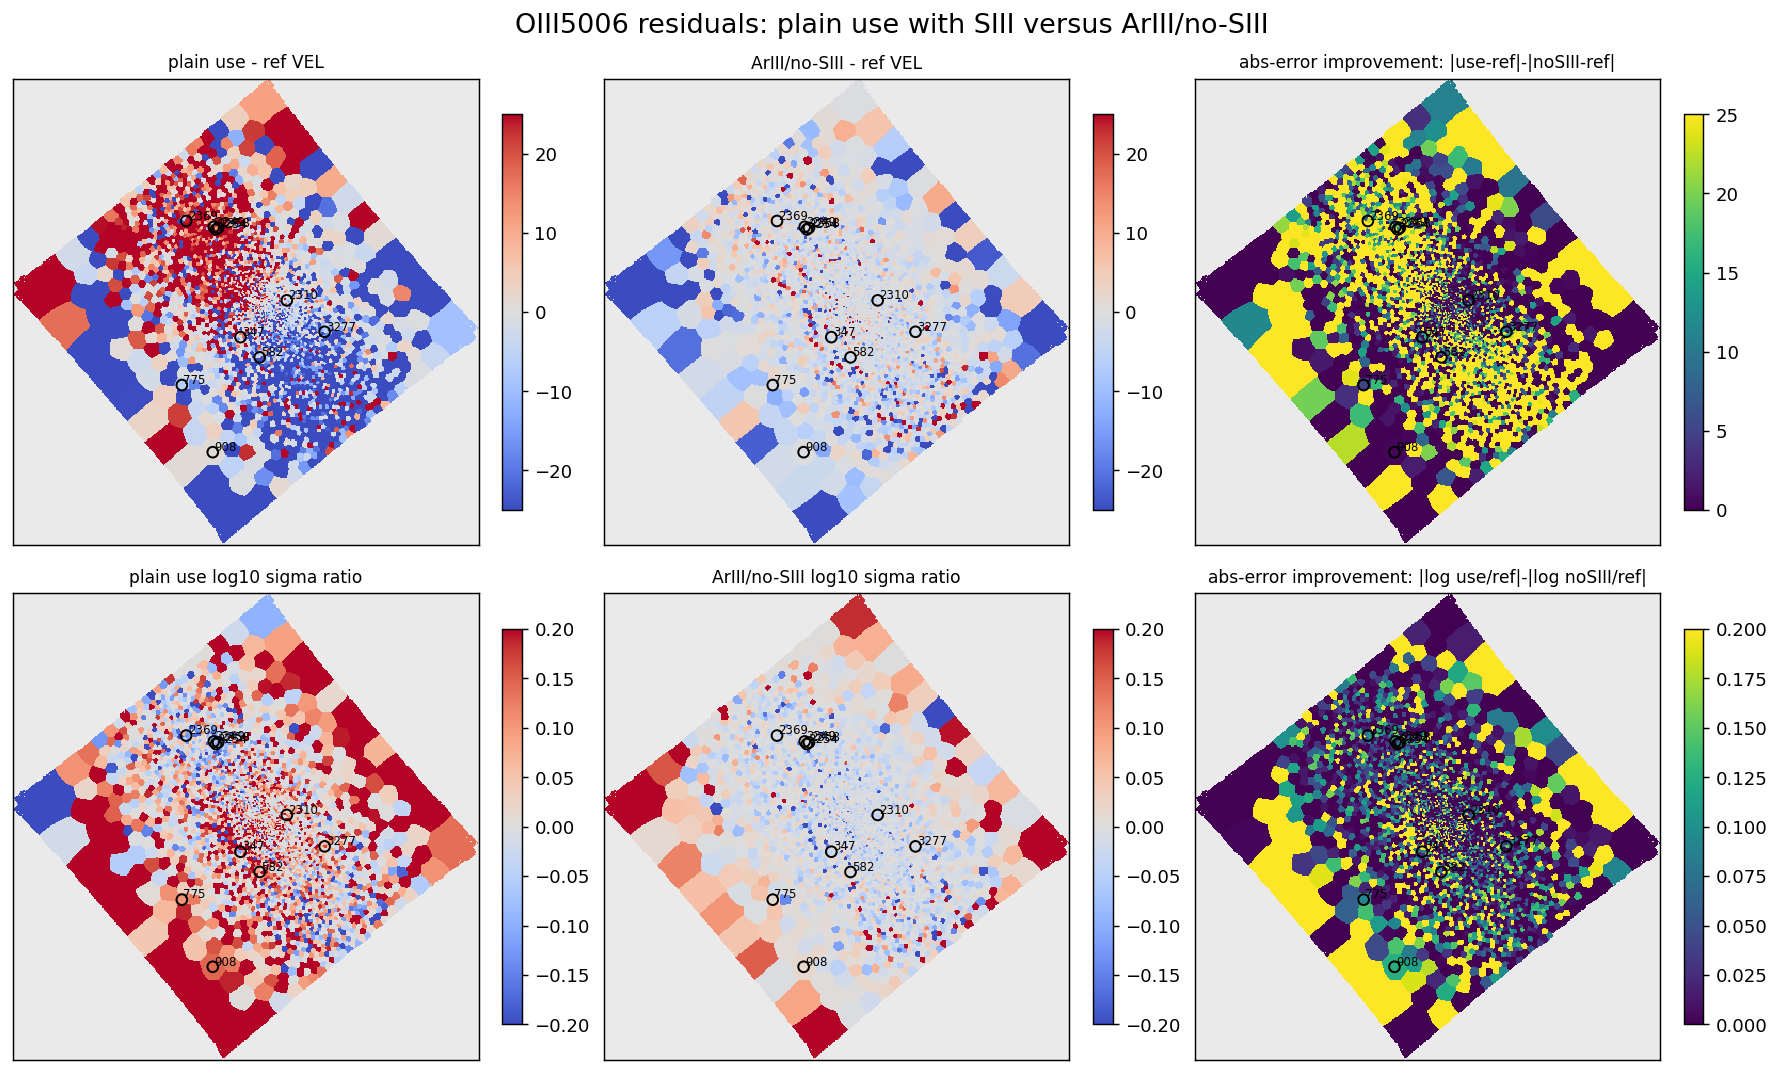

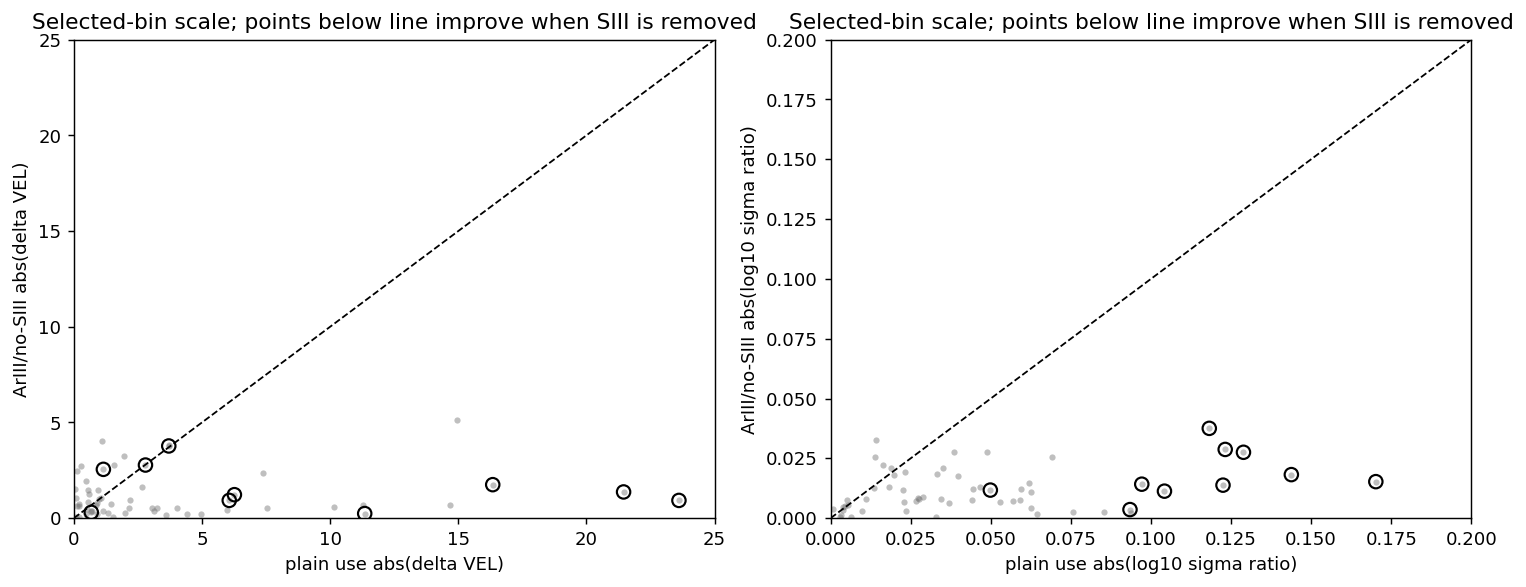

In [5]:
def rounded_selected_limit(values, floor=None, step=None):
    values = np.asarray(values, dtype=float)
    values = np.abs(values[np.isfinite(values)])
    if values.size == 0:
        return floor if floor is not None else 1.0
    lim = float(np.nanmax(values))
    if floor is not None:
        lim = max(lim, floor)
    if step is not None and step > 0:
        lim = float(np.ceil(lim / step) * step)
    return lim if np.isfinite(lim) and lim > 0 else (floor if floor is not None else 1.0)

vel_resid_lim = rounded_selected_limit(
    siii_driver_bins[['use_delta_vel', 'nosiii_delta_vel']].to_numpy().ravel(),
    floor=20.0,
    step=5.0,
)
vel_improvement_lim = rounded_selected_limit(
    siii_driver_bins['delta_abs_delta_vel_use_minus_nosiii'],
    floor=20.0,
    step=5.0,
)
sigma_log_lim = rounded_selected_limit(
    siii_driver_bins[['use_log10_sigma_ratio', 'nosiii_log10_sigma_ratio']].to_numpy().ravel(),
    floor=0.10,
    step=0.05,
)
sigma_improvement_lim = rounded_selected_limit(
    siii_driver_bins['delta_abs_log10_sigma_ratio_use_minus_nosiii'],
    floor=0.10,
    step=0.05,
)
map_scale_summary = pd.DataFrame([
    {'map_group': 'VEL residual maps', 'scale': f'+/- {vel_resid_lim:.1f} km/s', 'basis': 'max abs value among selected bins in the two residual panels'},
    {'map_group': 'VEL improvement map', 'scale': f'0 to {vel_improvement_lim:.1f} km/s', 'basis': 'max selected-bin improvement value'},
    {'map_group': 'SIGMA log-ratio maps', 'scale': f'+/- {sigma_log_lim:.2f} dex', 'basis': 'max abs value among selected bins in the two sigma panels'},
    {'map_group': 'SIGMA improvement map', 'scale': f'0 to {sigma_improvement_lim:.2f} dex', 'basis': 'max selected-bin improvement value'},
])
display(map_scale_summary)

fig, axes = plt.subplots(2, 3, figsize=(13.6, 8.2), constrained_layout=True)
fig.suptitle('OIII5006 residuals: plain use with SIII versus ArIII/no-SIII', fontsize=15)

panel_specs = [
    ('use_delta_vel', 'plain use - ref VEL', 'coolwarm', -vel_resid_lim, vel_resid_lim),
    ('nosiii_delta_vel', 'ArIII/no-SIII - ref VEL', 'coolwarm', -vel_resid_lim, vel_resid_lim),
    ('delta_abs_delta_vel_use_minus_nosiii', 'abs-error improvement: |use-ref|-|noSIII-ref|' , 'viridis', 0.0, vel_improvement_lim),
    ('use_log10_sigma_ratio', 'plain use log10 sigma ratio', 'coolwarm', -sigma_log_lim, sigma_log_lim),
    ('nosiii_log10_sigma_ratio', 'ArIII/no-SIII log10 sigma ratio', 'coolwarm', -sigma_log_lim, sigma_log_lim),
    ('delta_abs_log10_sigma_ratio_use_minus_nosiii', 'abs-error improvement: |log use/ref|-|log noSIII/ref|' , 'viridis', 0.0, sigma_improvement_lim),
]

for ax, (col, title, cmap_name, vmin, vmax) in zip(axes.ravel(), panel_specs):
    arr = np.full(baseline_bins.shape, np.nan, dtype=float)
    values_by_bin = bin_table.set_index('bin_id')[col]
    finite_bins = np.isfinite(baseline_bins) & (baseline_bins >= 0)
    flat_bins = baseline_bins[finite_bins].astype(int)
    arr[finite_bins] = values_by_bin.reindex(flat_bins).to_numpy()
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad('0.92')
    im = ax.imshow(np.ma.masked_invalid(arr), origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
    ax.scatter(siii_driver_bins['col'], siii_driver_bins['row'], s=35, facecolors='none', edgecolors='black', linewidths=1.1)
    for _, row in siii_driver_bins.iterrows():
        ax.text(row['col'] + 1.5, row['row'] + 1.5, str(int(row['bin_id'])), fontsize=6.5, color='black')
    ax.set_title(title, fontsize=9.5)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.82)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), constrained_layout=True)
plot_sample = high_snr_all.copy()
axes[0].scatter(plot_sample['use_abs_delta_vel'], plot_sample['nosiii_abs_delta_vel'], s=12, alpha=0.45, color='0.45', linewidths=0)
axes[0].scatter(siii_driver_bins['use_abs_delta_vel'], siii_driver_bins['nosiii_abs_delta_vel'], s=55, facecolors='none', edgecolors='black', linewidths=1.2)
max_vel = rounded_selected_limit(siii_driver_bins[['use_abs_delta_vel', 'nosiii_abs_delta_vel']].to_numpy().ravel(), floor=20.0, step=5.0)
axes[0].plot([0, max_vel], [0, max_vel], color='black', linestyle='--', linewidth=1)
axes[0].set_xlim(0, max_vel)
axes[0].set_ylim(0, max_vel)
axes[0].set_xlabel('plain use abs(delta VEL)')
axes[0].set_ylabel('ArIII/no-SIII abs(delta VEL)')
axes[0].set_title('Selected-bin scale; points below line improve when SIII is removed')

axes[1].scatter(plot_sample['use_abs_log10_sigma_ratio'], plot_sample['nosiii_abs_log10_sigma_ratio'], s=12, alpha=0.45, color='0.45', linewidths=0)
axes[1].scatter(siii_driver_bins['use_abs_log10_sigma_ratio'], siii_driver_bins['nosiii_abs_log10_sigma_ratio'], s=55, facecolors='none', edgecolors='black', linewidths=1.2)
max_sig = rounded_selected_limit(siii_driver_bins[['use_abs_log10_sigma_ratio', 'nosiii_abs_log10_sigma_ratio']].to_numpy().ravel(), floor=0.10, step=0.05)
axes[1].plot([0, max_sig], [0, max_sig], color='black', linestyle='--', linewidth=1)
axes[1].set_xlim(0, max_sig)
axes[1].set_ylim(0, max_sig)
axes[1].set_xlabel('plain use abs(log10 sigma ratio)')
axes[1].set_ylabel('ArIII/no-SIII abs(log10 sigma ratio)')
axes[1].set_title('Selected-bin scale; points below line improve when SIII is removed')
plt.show()


## OIII Pairwise And Direct Residual Plots

These plots restore the direct comparison views. For every residual panel, the sign convention is explicitly `comparison run - reference`, so the plain-use residual is `plain use - 7000/53 same-bin reference`. The improvement maps in the previous cell are a different diagnostic and should not be read as direct residual maps.


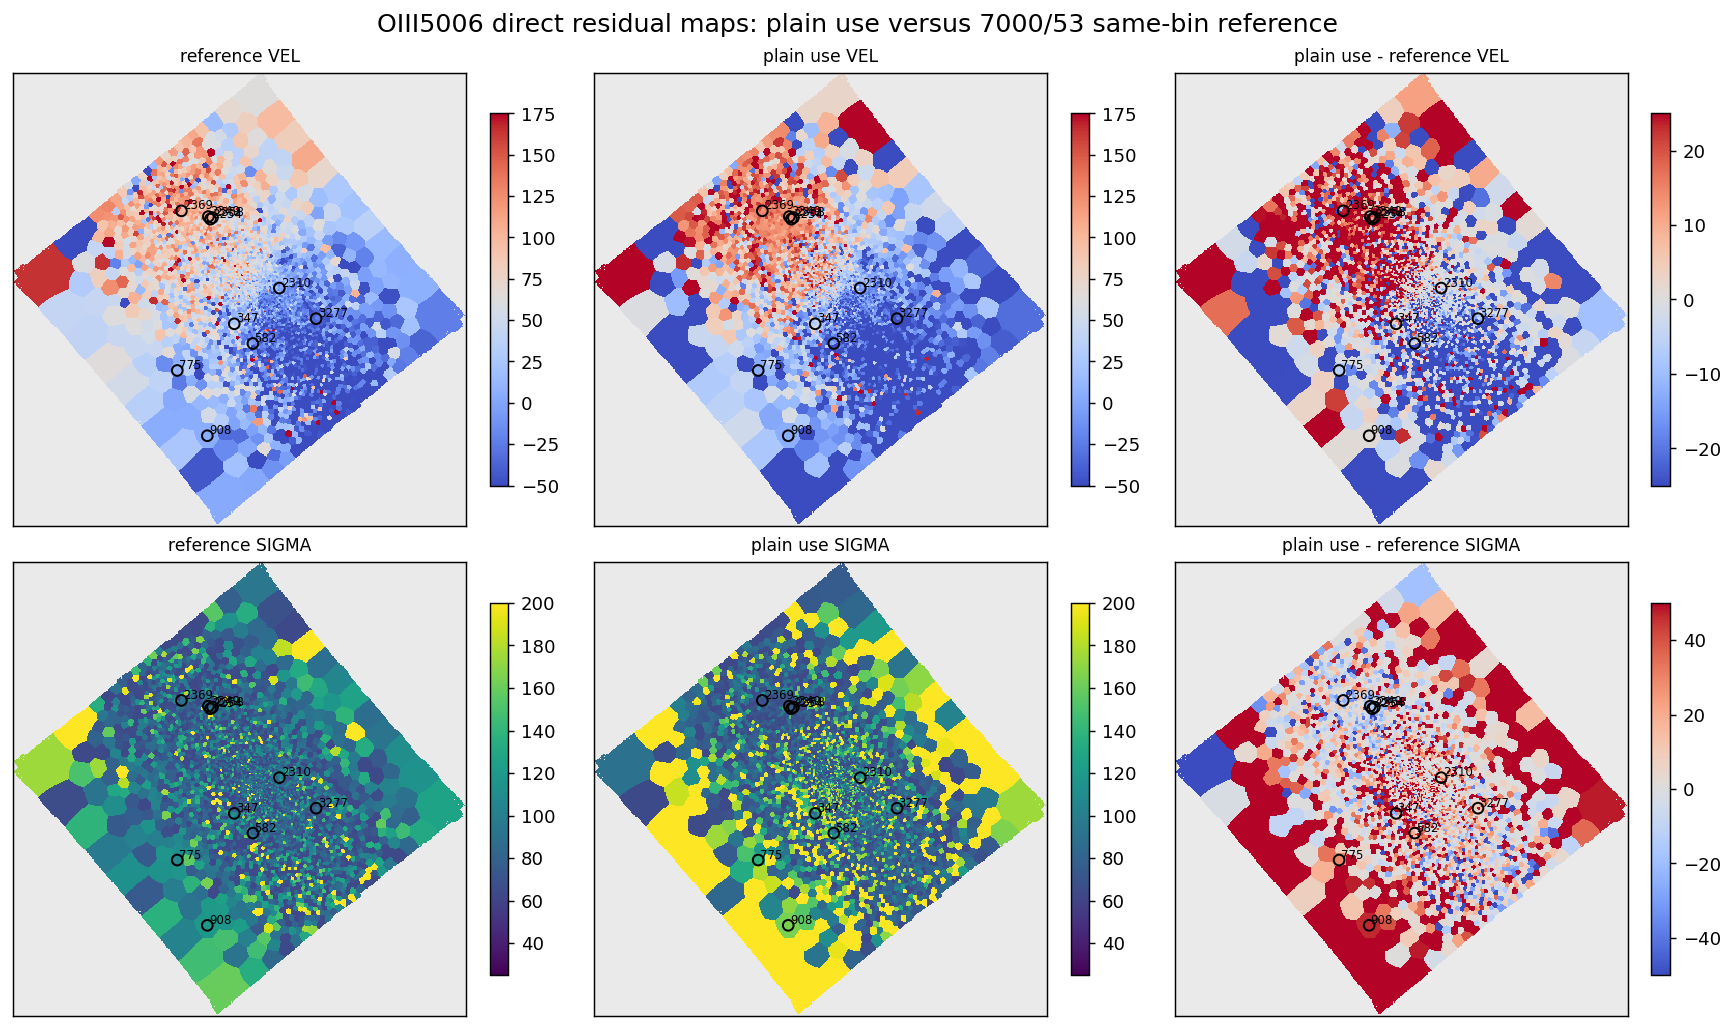

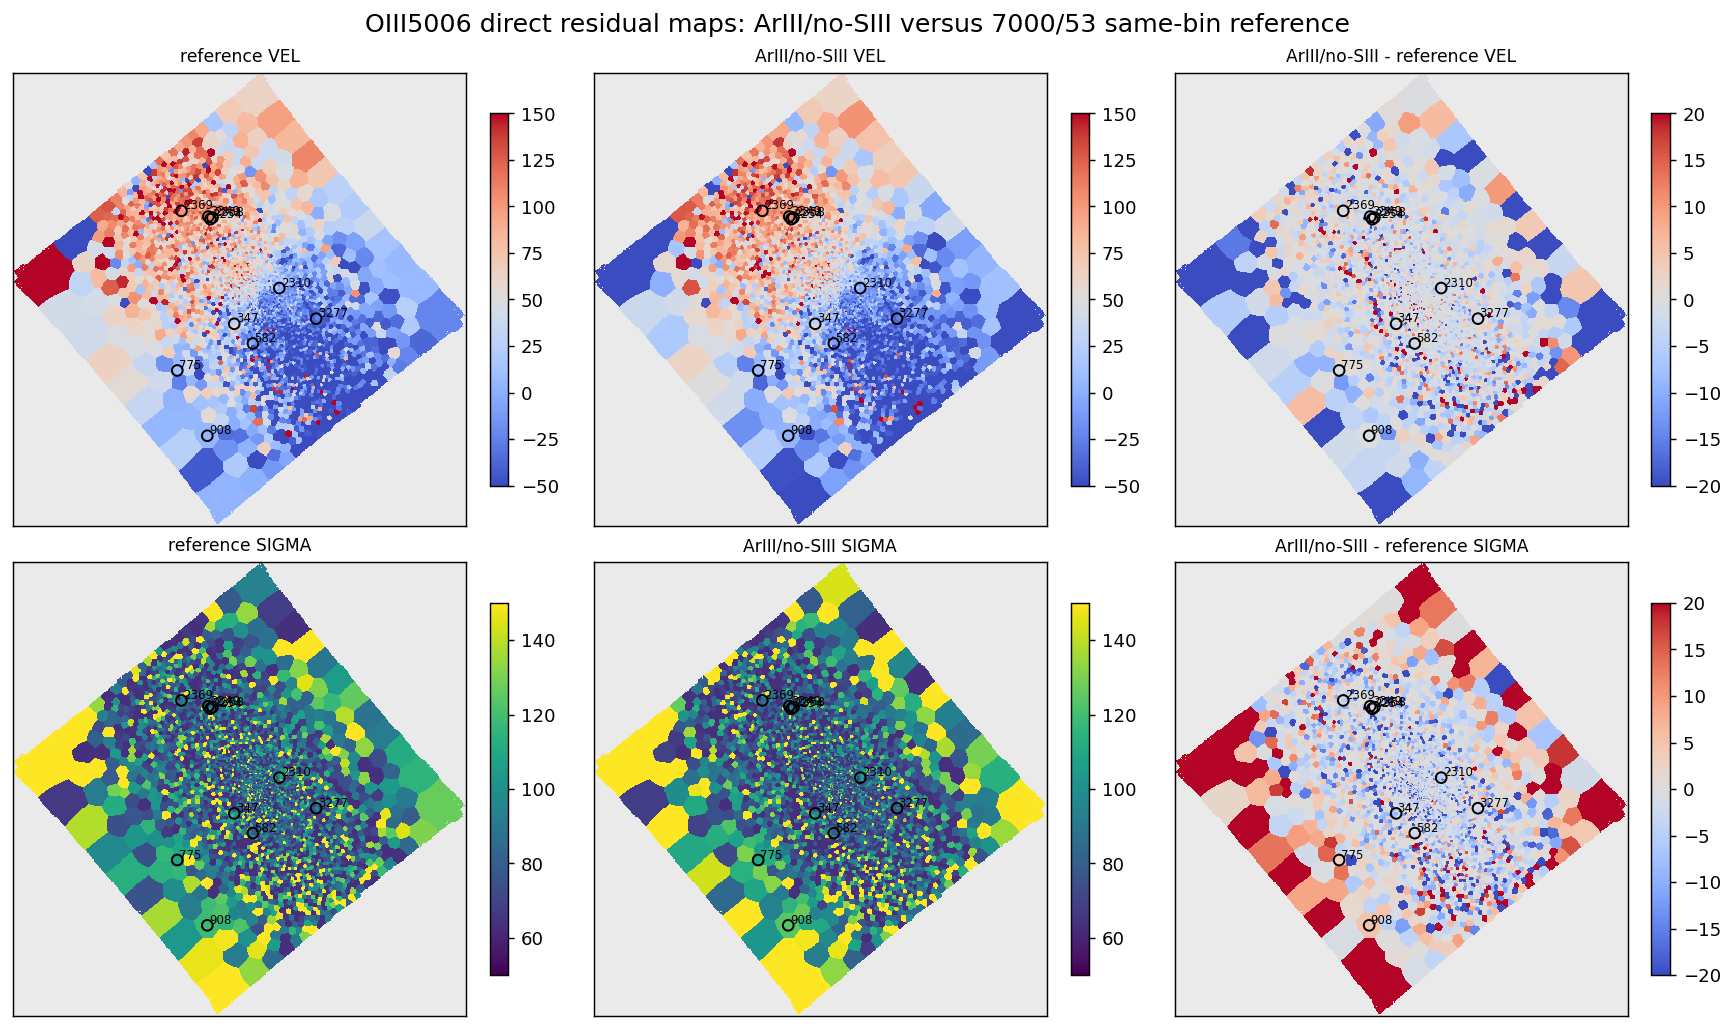

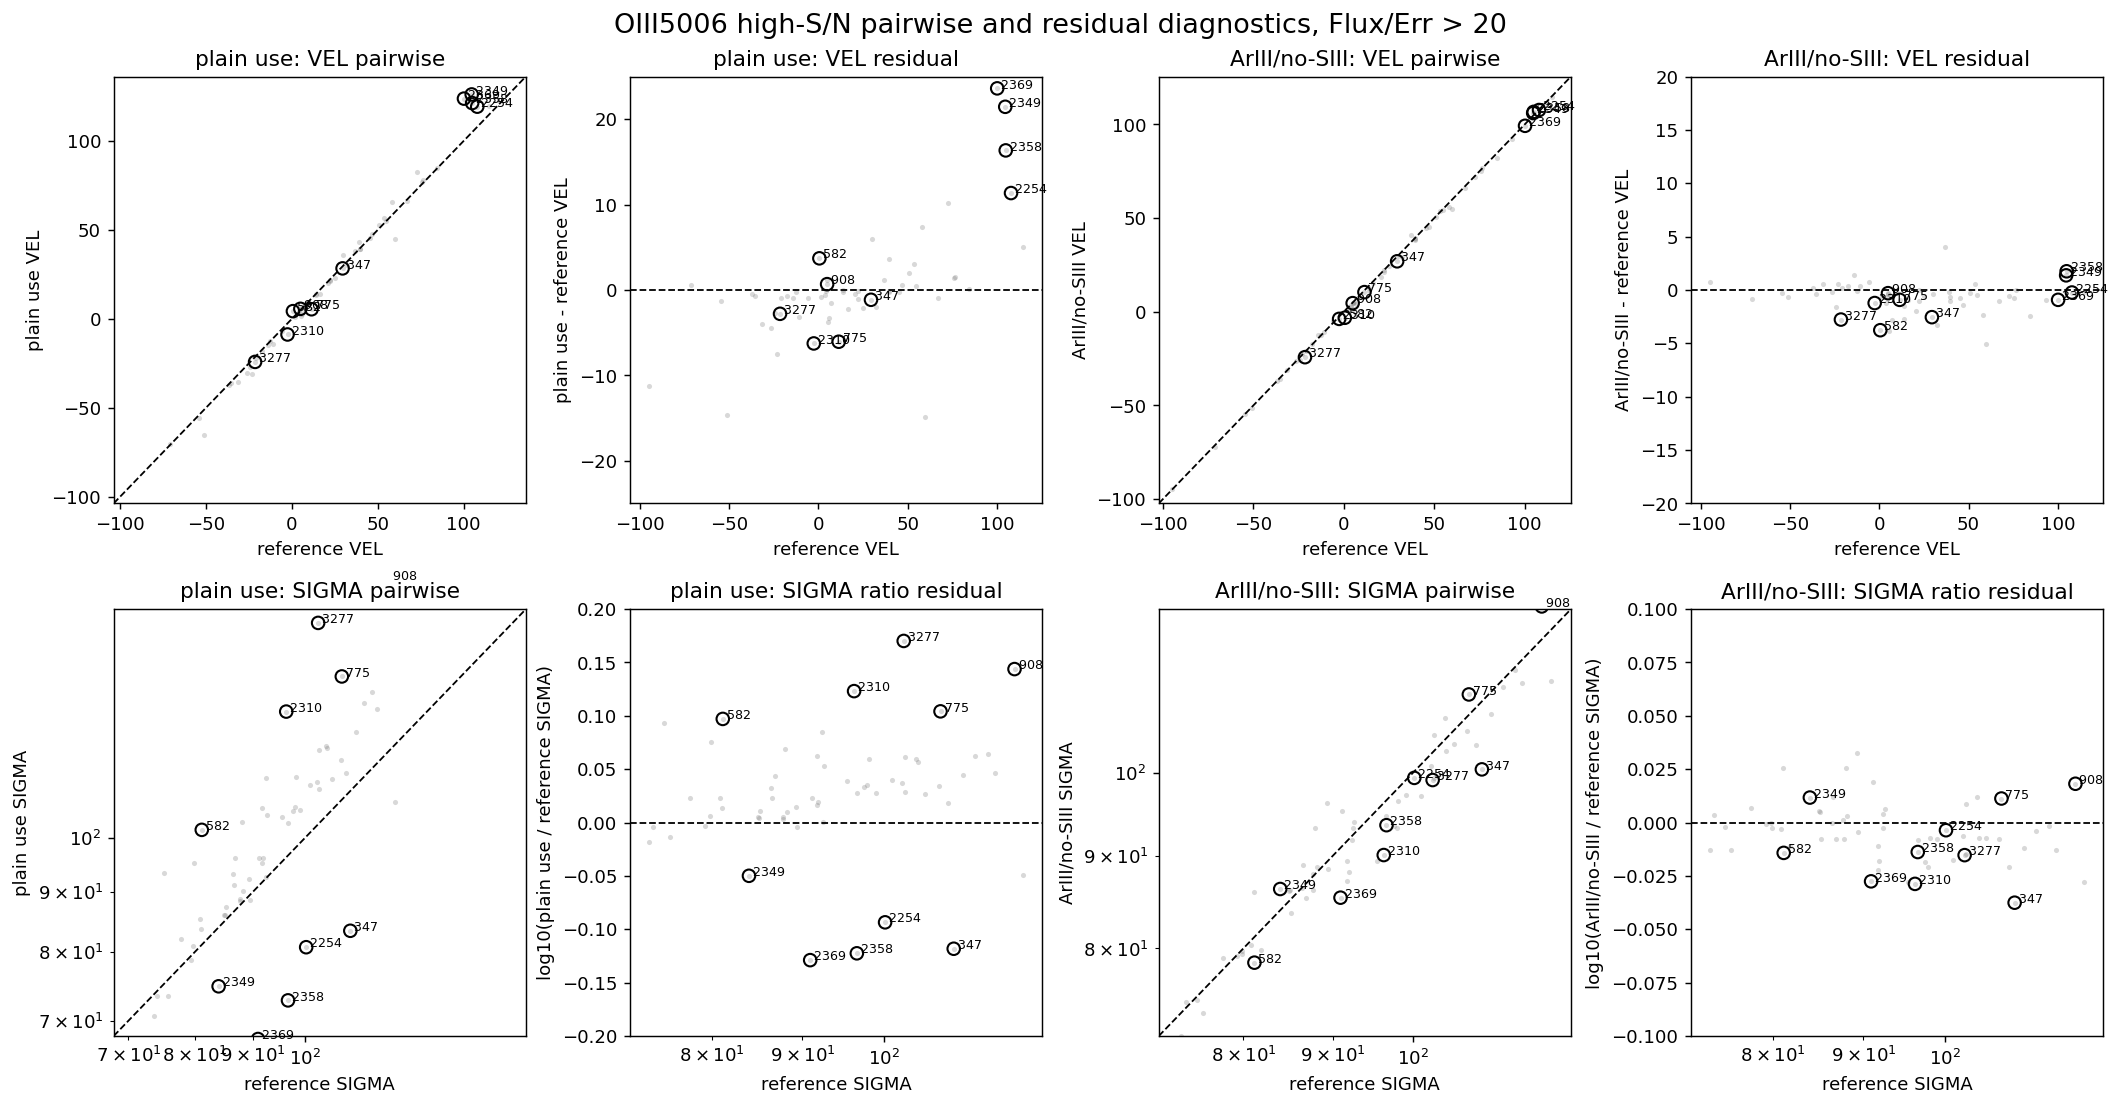

In [6]:
RUN_SHORT_LABELS = {
    SIII_RUN: 'plain use',
    ARIII_RUN: 'ArIII/no-SIII',
}
PREFIX_TO_RUN = {
    'use': SIII_RUN,
    'nosiii': ARIII_RUN,
}


def overlay_selected_map_bins(ax):
    ax.scatter(siii_driver_bins['col'], siii_driver_bins['row'], s=35, facecolors='none', edgecolors='black', linewidths=1.1)
    for _, row in siii_driver_bins.iterrows():
        ax.text(row['col'] + 1.5, row['row'] + 1.5, str(int(row['bin_id'])), fontsize=6.5, color='black')


def finite_concat(arrays):
    chunks = []
    for arr in arrays:
        vals = np.asarray(arr, dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size:
            chunks.append(vals)
    return np.concatenate(chunks) if chunks else np.array([])


def positive_robust_limits(arrays, p=(2, 98), fallback=(0, 1)):
    values = finite_concat(arrays)
    values = values[values > 0]
    if values.size == 0:
        return fallback
    lo, hi = np.nanpercentile(values, p)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return fallback
    pad = 0.06 * (hi - lo)
    return max(0.0, float(lo - pad)), float(hi + pad)




def selected_value_limits(prefix, quantity, floor=None, step=None, pad_fraction=0.08):
    cols = [f'ref_{quantity}', f'{prefix}_{quantity}']
    values = siii_driver_bins[cols].to_numpy().ravel().astype(float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return (0.0, floor if floor is not None else 1.0)
    lo = float(np.nanmin(values))
    hi = float(np.nanmax(values))
    pad = max((hi - lo) * pad_fraction, step if step else 1.0)
    lo -= pad
    hi += pad
    if floor is not None:
        lo = max(float(floor), lo)
    if step is not None and step > 0:
        lo = float(np.floor(lo / step) * step)
        hi = float(np.ceil(hi / step) * step)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        center = float(np.nanmedian(values)) if values.size else 0.0
        span = step if step else 1.0
        lo, hi = center - span, center + span
        if floor is not None:
            lo = max(float(floor), lo)
    return lo, hi

def direct_delta_map(run_key, quantity):
    arr = maps[run_key][quantity] - maps[BASELINE_RUN][quantity]
    arr[~np.isfinite(arr)] = np.nan
    return arr


def plot_direct_residual_triptych(prefix, run_key):
    run_label = RUN_SHORT_LABELS[run_key]
    vel_ref = maps[BASELINE_RUN]['VEL']
    vel_run = maps[run_key]['VEL']
    sig_ref = maps[BASELINE_RUN]['SIGMA']
    sig_run = maps[run_key]['SIGMA']
    delta_vel = direct_delta_map(run_key, 'VEL')
    delta_sigma = direct_delta_map(run_key, 'SIGMA')

    vel_value_limits = selected_value_limits(prefix, 'vel', floor=None, step=25.0)
    sigma_value_limits = selected_value_limits(prefix, 'sigma', floor=0.0, step=25.0)
    vel_delta_lim = rounded_selected_limit(
        siii_driver_bins[f'{prefix}_delta_vel'],
        floor=20.0,
        step=5.0,
    )
    sigma_delta_lim = rounded_selected_limit(
        siii_driver_bins[f'{prefix}_delta_sigma'],
        floor=20.0,
        step=5.0,
    )

    panels = [
        (vel_ref, 'reference VEL', 'coolwarm', vel_value_limits[0], vel_value_limits[1]),
        (vel_run, f'{run_label} VEL', 'coolwarm', vel_value_limits[0], vel_value_limits[1]),
        (delta_vel, f'{run_label} - reference VEL', 'coolwarm', -vel_delta_lim, vel_delta_lim),
        (sig_ref, 'reference SIGMA', 'viridis', sigma_value_limits[0], sigma_value_limits[1]),
        (sig_run, f'{run_label} SIGMA', 'viridis', sigma_value_limits[0], sigma_value_limits[1]),
        (delta_sigma, f'{run_label} - reference SIGMA', 'coolwarm', -sigma_delta_lim, sigma_delta_lim),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(13.4, 7.8), constrained_layout=True)
    fig.suptitle(f'OIII5006 direct residual maps: {run_label} versus 7000/53 same-bin reference', fontsize=14)
    for ax, (arr, title, cmap_name, vmin, vmax) in zip(axes.ravel(), panels):
        cmap = plt.get_cmap(cmap_name).copy()
        cmap.set_bad('0.92')
        im = ax.imshow(np.ma.masked_invalid(arr), origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
        overlay_selected_map_bins(ax)
        ax.set_title(title, fontsize=9.5)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, shrink=0.82)
    plt.show()


for prefix, run_key in PREFIX_TO_RUN.items():
    plot_direct_residual_triptych(prefix, run_key)


def scatter_selected_bins(ax, data, x_col, y_col, color='black'):
    selected = data[data['bin_id'].isin(siii_driver_bins['bin_id'])].copy()
    ax.scatter(selected[x_col], selected[y_col], s=48, facecolors='none', edgecolors=color, linewidths=1.15, zorder=5)
    for _, row in selected.iterrows():
        ax.text(row[x_col], row[y_col], f' {int(row["bin_id"])}', fontsize=7, color=color, zorder=6)


def pairwise_sample_for_prefix(prefix):
    needed = [
        'ref_vel', f'{prefix}_vel', f'{prefix}_delta_vel',
        'ref_sigma', f'{prefix}_sigma', f'{prefix}_log10_sigma_ratio',
        'ref_fluxerr', f'{prefix}_fluxerr',
    ]
    sample = bin_table.copy()
    finite = np.ones(len(sample), dtype=bool)
    for col in needed:
        finite &= np.isfinite(sample[col])
    finite &= sample[['ref_fluxerr', f'{prefix}_fluxerr']].min(axis=1).to_numpy() > HIGH_SNR_CUT
    finite &= (sample['ref_sigma'].to_numpy() > 0) & (sample[f'{prefix}_sigma'].to_numpy() > 0)
    sample = sample[finite].copy()
    if len(sample) > 25000:
        sample = sample.sample(25000, random_state=12)
    return sample

fig, axes = plt.subplots(2, 4, figsize=(16.2, 8.4), constrained_layout=True)
fig.suptitle(f'OIII5006 high-S/N pairwise and residual diagnostics, Flux/Err > {HIGH_SNR_CUT}', fontsize=15)

for j, (prefix, run_key) in enumerate(PREFIX_TO_RUN.items()):
    run_label = RUN_SHORT_LABELS[run_key]
    data = pairwise_sample_for_prefix(prefix)

    ax = axes[0, 2*j]
    lo, hi = robust_limits(data[['ref_vel', f'{prefix}_vel']].to_numpy().ravel(), p=(1, 99), fallback=(-150, 150))
    ax.scatter(data['ref_vel'], data[f'{prefix}_vel'], s=8, alpha=0.28, linewidths=0, color='0.45')
    ax.plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=1)
    scatter_selected_bins(ax, data, 'ref_vel', f'{prefix}_vel')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel('reference VEL')
    ax.set_ylabel(f'{run_label} VEL')
    ax.set_title(f'{run_label}: VEL pairwise')

    ax = axes[0, 2*j + 1]
    vel_lim = rounded_selected_limit(siii_driver_bins[f'{prefix}_delta_vel'], floor=20.0, step=5.0)
    ax.scatter(data['ref_vel'], data[f'{prefix}_delta_vel'], s=8, alpha=0.28, linewidths=0, color='0.45')
    scatter_selected_bins(ax, data, 'ref_vel', f'{prefix}_delta_vel')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_ylim(-vel_lim, vel_lim)
    ax.set_xlabel('reference VEL')
    ax.set_ylabel(f'{run_label} - reference VEL')
    ax.set_title(f'{run_label}: VEL residual')

    ax = axes[1, 2*j]
    sigma_values = data[['ref_sigma', f'{prefix}_sigma']].to_numpy().ravel()
    sigma_values = sigma_values[np.isfinite(sigma_values) & (sigma_values > 0)]
    slo_log, shi_log = robust_limits(np.log10(sigma_values), p=(1, 99), fallback=(np.log10(30), np.log10(400)))
    slo, shi = 10**slo_log, 10**shi_log
    ax.scatter(data['ref_sigma'], data[f'{prefix}_sigma'], s=8, alpha=0.28, linewidths=0, color='0.45')
    ax.plot([slo, shi], [slo, shi], color='black', linestyle='--', linewidth=1)
    scatter_selected_bins(ax, data, 'ref_sigma', f'{prefix}_sigma')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(slo, shi)
    ax.set_ylim(slo, shi)
    ax.set_xlabel('reference SIGMA')
    ax.set_ylabel(f'{run_label} SIGMA')
    ax.set_title(f'{run_label}: SIGMA pairwise')

    ax = axes[1, 2*j + 1]
    log_lim = rounded_selected_limit(siii_driver_bins[f'{prefix}_log10_sigma_ratio'], floor=0.10, step=0.05)
    ax.scatter(data['ref_sigma'], data[f'{prefix}_log10_sigma_ratio'], s=8, alpha=0.28, linewidths=0, color='0.45')
    scatter_selected_bins(ax, data, 'ref_sigma', f'{prefix}_log10_sigma_ratio')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xscale('log')
    ax.set_ylim(-log_lim, log_lim)
    ax.set_xlabel('reference SIGMA')
    ax.set_ylabel(f'log10({run_label} / reference SIGMA)')
    ax.set_title(f'{run_label}: SIGMA ratio residual')

plt.show()


## GAS-Map S/N For SIII Versus ArIII

If SIII is driving the problem, the next question is whether its GAS maps show apparently significant constraints in exactly the bins where OIII is pulled away from the reference. This table compares fitted line `Flux/Err`, fitted velocity/sigma, and offsets from that run's OIII kinematics.


In [7]:
LINE_REQUIRED_SUFFIXES = ['FLUX', 'FLUX_ERR', 'VEL', 'VEL_ERR', 'SIGMA', 'SIGMA_ERR', 'SIGMA_CORR']
DIAGNOSTIC_LINES = [
    {'line_id': 'SIII6312', 'run_key': SIII_RUN, 'label': '[S III] 6312 in plain use'},
    {'line_id': 'SIII9068', 'run_key': SIII_RUN, 'label': '[S III] 9068 in plain use'},
    {'line_id': 'ARIII7135', 'run_key': ARIII_RUN, 'label': '[Ar III] 7135 in ArIII/no-SIII'},
]

gas_extnames_by_run = {run_key: set(fits_extnames(RUNS[run_key]['gas_path'])) for run_key in [SIII_RUN, ARIII_RUN, BASELINE_RUN]}
line_maps = {}
line_availability_rows = []
for spec in DIAGNOSTIC_LINES:
    line_id = spec['line_id']
    run_key = spec['run_key']
    extnames = gas_extnames_by_run[run_key]
    required = [f'{line_id}_{suffix}' for suffix in LINE_REQUIRED_SUFFIXES]
    missing = [ext for ext in required if ext not in extnames]
    available = len(missing) == 0
    line_availability_rows.append({
        'line_id': line_id,
        'line_label': spec['label'],
        'run_key': run_key,
        'run_label': RUNS[run_key]['label'],
        'available': available,
        'missing_extensions': ', '.join(missing),
    })
    if available:
        line_maps[(run_key, line_id)] = {
            suffix.lower(): read_map(RUNS[run_key]['gas_path'], f'{line_id}_{suffix}')
            for suffix in LINE_REQUIRED_SUFFIXES
        }
line_availability = pd.DataFrame(line_availability_rows)
display(line_availability)


def median_map_value_for_bin(arr, bin_id):
    values = arr[baseline_bins == int(bin_id)]
    values = values[np.isfinite(values)]
    return float(np.nanmedian(values)) if values.size else np.nan


def line_bin_table_for_spec(spec, bins=None):
    run_key = spec['run_key']
    line_id = spec['line_id']
    if (run_key, line_id) not in line_maps:
        return pd.DataFrame()
    line_map = line_maps[(run_key, line_id)]
    prefix = RUN_PREFIX[run_key]
    source = bin_table if bins is None else bins
    rows = []
    for _, oiii_row in source.iterrows():
        bin_id = int(oiii_row['bin_id'])
        flux = median_map_value_for_bin(line_map['flux'], bin_id)
        flux_err = median_map_value_for_bin(line_map['flux_err'], bin_id)
        fluxerr = flux / flux_err if np.isfinite(flux) and np.isfinite(flux_err) and flux_err > 0 else np.nan
        vel = median_map_value_for_bin(line_map['vel'], bin_id)
        sigma = median_map_value_for_bin(line_map['sigma'], bin_id)
        vel_err = median_map_value_for_bin(line_map['vel_err'], bin_id)
        sigma_err = median_map_value_for_bin(line_map['sigma_err'], bin_id)
        sigma_corr = median_map_value_for_bin(line_map['sigma_corr'], bin_id)
        rows.append({
            'line_id': line_id,
            'line_label': spec['label'],
            'run_key': run_key,
            'run_label': RUNS[run_key]['label'],
            'bin_id': bin_id,
            'row': oiii_row['row'],
            'col': oiii_row['col'],
            'n_spaxels': oiii_row['n_spaxels'],
            'oiii_use_to_nosiii_improvement_score': oiii_row.get('use_to_nosiii_improvement_score', np.nan),
            'oiii_use_badness_score': oiii_row.get('use_badness_score', np.nan),
            'line_flux': flux,
            'line_flux_err': flux_err,
            'line_fluxerr': fluxerr,
            'line_vel': vel,
            'line_sigma': sigma,
            'line_vel_err': vel_err,
            'line_sigma_err': sigma_err,
            'line_sigma_corr': sigma_corr,
            'same_run_oiii_fluxerr': oiii_row[f'{prefix}_fluxerr'],
            'same_run_oiii_vel': oiii_row[f'{prefix}_vel'],
            'same_run_oiii_sigma': oiii_row[f'{prefix}_sigma'],
            'line_minus_oiii_vel': vel - oiii_row[f'{prefix}_vel'],
            'line_minus_oiii_sigma': sigma - oiii_row[f'{prefix}_sigma'],
        })
    return pd.DataFrame(rows)

all_line_bin_tables = []
selected_line_tables = []
for spec in DIAGNOSTIC_LINES:
    all_line_bin_tables.append(line_bin_table_for_spec(spec))
    selected_line_tables.append(line_bin_table_for_spec(spec, siii_driver_bins))
line_bin_table = pd.concat(all_line_bin_tables, ignore_index=True)
selected_line_table = pd.concat(selected_line_tables, ignore_index=True)

line_population_rows = []
for (run_key, line_id), subset in line_bin_table.groupby(['run_key', 'line_id']):
    finite = subset[np.isfinite(subset['line_fluxerr'])]
    line_population_rows.append({
        'run_key': run_key,
        'line_id': line_id,
        'n_finite_fluxerr_bins': int(len(finite)),
        'median_fluxerr': float(np.nanmedian(finite['line_fluxerr'])) if len(finite) else np.nan,
        'p90_fluxerr': float(np.nanpercentile(finite['line_fluxerr'], 90)) if len(finite) else np.nan,
        'n_fluxerr_gt_3': int(np.count_nonzero(finite['line_fluxerr'] > 3)),
        'n_fluxerr_gt_5': int(np.count_nonzero(finite['line_fluxerr'] > 5)),
        'n_fluxerr_gt_10': int(np.count_nonzero(finite['line_fluxerr'] > 10)),
        'median_abs_line_minus_oiii_vel': float(np.nanmedian(np.abs(finite['line_minus_oiii_vel']))) if len(finite) else np.nan,
        'median_abs_line_minus_oiii_sigma': float(np.nanmedian(np.abs(finite['line_minus_oiii_sigma']))) if len(finite) else np.nan,
    })
line_population_summary = pd.DataFrame(line_population_rows)
display(line_population_summary)

selected_line_cols = [
    'line_id', 'bin_id', 'line_fluxerr', 'line_flux', 'line_flux_err', 'line_vel', 'line_sigma',
    'line_vel_err', 'line_sigma_err', 'line_minus_oiii_vel', 'line_minus_oiii_sigma',
    'same_run_oiii_fluxerr', 'oiii_use_badness_score', 'oiii_use_to_nosiii_improvement_score',
]
display(selected_line_table[selected_line_cols].sort_values(['line_id', 'oiii_use_to_nosiii_improvement_score'], ascending=[True, False]))


,line_id,line_label,run_key,run_label,available,missing_extensions
0,SIII6312,[S III] 6312 in plain use,use_with_siii,"7.6.8 9100/40 plain use: SIII on, ArIII off",True,
1,SIII9068,[S III] 9068 in plain use,use_with_siii,"7.6.8 9100/40 plain use: SIII on, ArIII off",True,
2,ARIII7135,[Ar III] 7135 in ArIII/no-SIII,ariii_no_siii,"7.6.8 9100/40 ArIII on, SIII off",True,


,run_key,line_id,n_finite_fluxerr_bins,median_fluxerr,p90_fluxerr,n_fluxerr_gt_3,n_fluxerr_gt_5,n_fluxerr_gt_10,median_abs_line_minus_oiii_vel,median_abs_line_minus_oiii_sigma
0,ariii_no_siii,ARIII7135,4032,0.000000,2.110950,202,63,32,0.0,14.078387
1,use_with_siii,SIII6312,4032,0.385955,5.147928,770,412,203,0.0,9.222266
2,use_with_siii,SIII9068,4032,5.705434,10.743027,2624,2203,557,0.0,18.305023


,line_id,bin_id,line_fluxerr,line_flux,line_flux_err,line_vel,line_sigma,line_vel_err,line_sigma_err,line_minus_oiii_vel,line_minus_oiii_sigma,same_run_oiii_fluxerr,oiii_use_badness_score,oiii_use_to_nosiii_improvement_score
20,ARIII7135,2369,0.000000,0.000000,2.498437,99.240522,72.192873,5.490552,8.418415,0.0,-13.126791,21.896545,1.331417,1.129373
21,ARIII7135,3277,2.734966,11.288776,4.127574,-24.223900,88.029288,6.604939,8.732672,0.0,-11.050426,20.686064,1.190537,1.033374
22,ARIII7135,2358,1.738567,5.871441,3.377174,106.684124,81.759485,6.075824,8.424000,0.0,-11.793963,21.004256,1.143493,1.016577
23,ARIII7135,908,7.238813,3.105294,0.428978,4.611406,114.870380,6.981442,8.325681,0.0,-8.672480,23.693144,0.972451,0.845128
24,ARIII7135,2254,0.000000,0.000000,3.635586,107.664281,88.333991,6.544158,8.572924,0.0,-11.016541,21.438146,0.850031,0.821369
25,ARIII7135,2310,1.572819,11.768714,7.482562,-3.786288,77.748736,5.838967,8.320285,0.0,-12.320682,20.726680,0.946488,0.730523
26,ARIII7135,775,2.729328,1.952075,0.715222,10.495413,100.673883,6.080867,7.633234,0.0,-9.792695,25.541459,0.816058,0.722340
27,ARIII7135,2349,0.405721,1.505984,3.711868,106.035426,73.307861,5.264214,7.958749,0.0,-12.957292,22.644944,0.761429,0.655887
28,ARIII7135,582,4.822372,18.822695,3.903203,-3.187625,64.056299,4.903299,8.559719,0.0,-14.498418,21.731921,0.721628,0.551575
29,ARIII7135,347,5.172304,18.781168,3.631103,26.937025,89.546480,5.103340,6.526057,0.0,-10.883626,26.845178,0.811108,0.509905


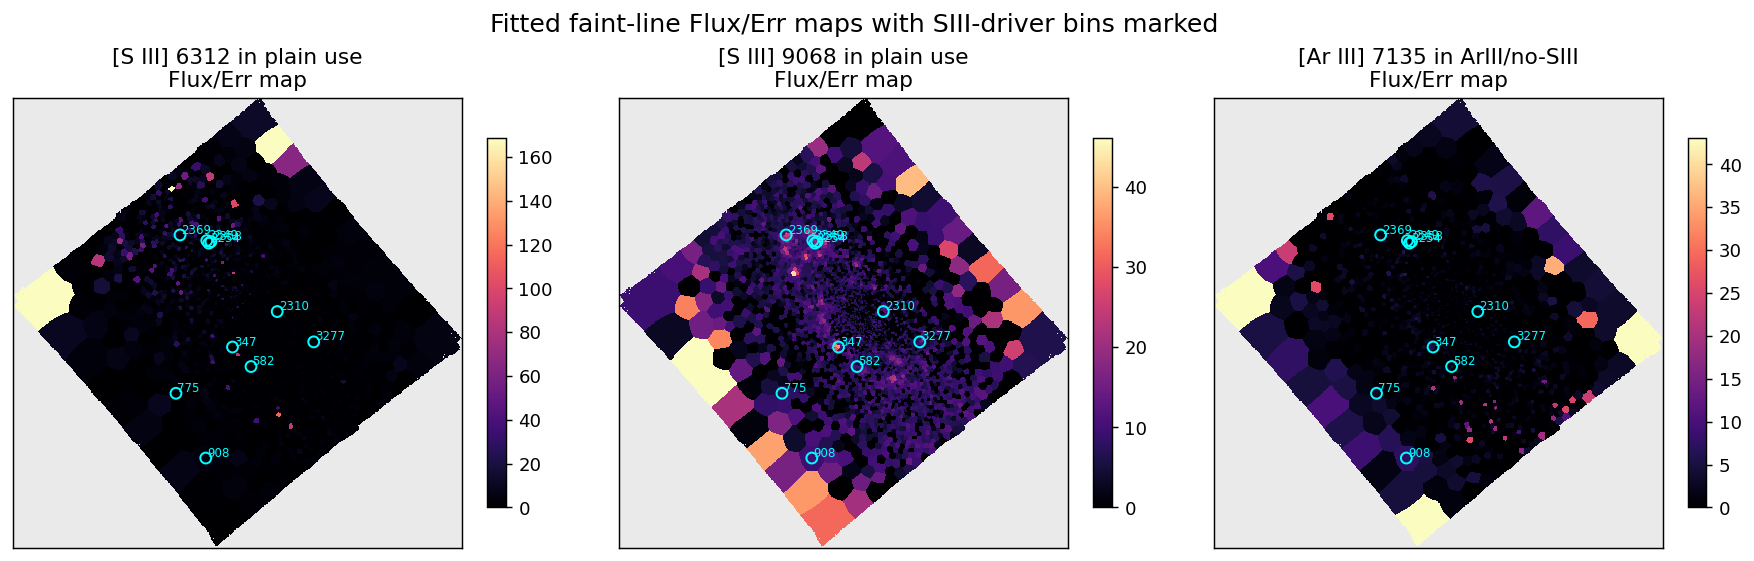

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.2), constrained_layout=True)
fig.suptitle('Fitted faint-line Flux/Err maps with SIII-driver bins marked', fontsize=14)
for ax, spec in zip(axes, DIAGNOSTIC_LINES):
    run_key = spec['run_key']
    line_id = spec['line_id']
    if (run_key, line_id) not in line_maps:
        ax.set_title(f'{line_id}: unavailable')
        ax.axis('off')
        continue
    flux = line_maps[(run_key, line_id)]['flux']
    err = line_maps[(run_key, line_id)]['flux_err']
    fluxerr = np.full(flux.shape, np.nan, dtype=float)
    ok = np.isfinite(flux) & np.isfinite(err) & (err > 0)
    fluxerr[ok] = flux[ok] / err[ok]
    cmap = plt.get_cmap('magma').copy()
    cmap.set_bad('0.92')
    vmax = np.nanpercentile(fluxerr[np.isfinite(fluxerr)], 98) if np.isfinite(fluxerr).any() else 1.0
    vmax = max(vmax, 3.0)
    im = ax.imshow(np.ma.masked_invalid(fluxerr), origin='lower', cmap=cmap, vmin=0, vmax=vmax, interpolation='nearest')
    ax.scatter(siii_driver_bins['col'], siii_driver_bins['row'], s=36, facecolors='none', edgecolors='cyan', linewidths=1.1)
    for _, row in siii_driver_bins.iterrows():
        ax.text(row['col'] + 1.5, row['row'] + 1.5, str(int(row['bin_id'])), fontsize=6.5, color='cyan')
    ax.set_title(f'{spec["label"]}\nFlux/Err map')
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.82)
plt.show()


## Real Line Cube Spectrum, Continuum Cube Check, And Real GAS Best-Fit Spectra

The black spectrum is always the same continuum-subtracted line cube from the 7000 same-bin folder. The model curves are not inferred Gaussians: they are read directly from each run's `IC3392_gas_bestfit_bin.fits` `GAS_BESTFIT` table. Each panel tries to show the line-cube spectrum plus GAS best-fit spectra from the 7000 same-bin, plain-use, and ArIII/no-SIII runs. A model curve is skipped only when that run has no wavelength coverage in the requested window.

The continuum cube is also read for the same bins, but it is treated as a separate diagnostic: if the suspicious feature is present in the line cube and in low-OIII regions, but not as a sharp feature in the continuum cube, the evidence points to line-cube/sky residual structure rather than stellar-continuum modelling.


In [9]:
def cube_path_for_kind(cube_kind):
    if cube_kind == 'line_cube':
        return RUNS[LINECUBE_RUN]['line_cube_path']
    if cube_kind == 'cont_cube':
        return RUNS[CONTCUBE_RUN]['cont_cube_path']
    raise ValueError(f'Unknown cube_kind={cube_kind!r}')


def get_cube_slab(cube_kind, rest_air_a, wave_half_width=45.0):
    path = cube_path_for_kind(cube_kind)
    systemic_center = rest_air_a * (1.0 + REDSHIFT)
    with fits.open(path, memmap=True) as hdul:
        cube = hdul[0].data
        wave = wavelength_from_header(hdul[0].header, cube.shape[0])
        wave_mask = (wave >= systemic_center - wave_half_width) & (wave <= systemic_center + wave_half_width)
        if not np.any(wave_mask):
            return wave[wave_mask], np.empty((0,) + cube.shape[1:], dtype=float)
        cube_cut = np.array(cube[wave_mask, :, :], dtype=float)
        wave_cut = wave[wave_mask]
    return wave_cut, cube_cut


def get_linecube_slab(rest_air_a, wave_half_width=45.0):
    return get_cube_slab('line_cube', rest_air_a, wave_half_width=wave_half_width)


def get_contcube_slab(rest_air_a, wave_half_width=45.0):
    return get_cube_slab('cont_cube', rest_air_a, wave_half_width=wave_half_width)


def local_zero_correct(wave, spectrum, systemic_center, continuum_inner=20.0):
    sideband = (np.abs(wave - systemic_center) >= continuum_inner) & np.isfinite(wave) & np.isfinite(spectrum)
    if np.count_nonzero(sideband) >= 4:
        coeff = np.polyfit(wave[sideband], spectrum[sideband], deg=1)
        zero = np.polyval(coeff, wave)
    else:
        zero = np.full_like(spectrum, np.nanmedian(spectrum))
    return spectrum - zero, zero, sideband


def abs_peak_and_wave(wave, spectrum, mask):
    if not np.any(mask):
        return np.nan, np.nan
    values = np.asarray(spectrum[mask], dtype=float)
    waves = np.asarray(wave[mask], dtype=float)
    finite = np.isfinite(values) & np.isfinite(waves)
    if not np.any(finite):
        return np.nan, np.nan
    idx = np.nanargmax(np.abs(values[finite]))
    return float(np.abs(values[finite][idx])), float(waves[finite][idx])


def spectral_profile_metrics(wave, spectrum, systemic_center, line_half_width=12.0, continuum_inner=20.0):
    corrected, zero, sideband = local_zero_correct(wave, spectrum, systemic_center, continuum_inner=continuum_inner)
    line_window = np.abs(wave - systemic_center) <= line_half_width
    side_rms = robust_sigma(corrected[sideband])
    line_rms = robust_sigma(corrected[line_window])
    peak_abs, peak_wave = abs_peak_and_wave(wave, corrected, line_window)
    dw = float(np.nanmedian(np.diff(wave))) if len(wave) > 1 else np.nan
    line_integral = np.trapezoid(corrected[line_window], wave[line_window]) if np.count_nonzero(line_window) >= 2 else np.nan
    integral_noise = side_rms * np.sqrt(np.count_nonzero(line_window)) * dw if np.isfinite(side_rms) and np.isfinite(dw) else np.nan
    integral_snr = line_integral / integral_noise if np.isfinite(integral_noise) and integral_noise > 0 else np.nan
    metrics = {
        'sideband_rms': side_rms,
        'line_window_rms': line_rms,
        'line_window_rms_over_sideband': line_rms / side_rms if np.isfinite(side_rms) and side_rms > 0 else np.nan,
        'peak_abs_over_sideband': peak_abs / side_rms if np.isfinite(side_rms) and side_rms > 0 else np.nan,
        'peak_wave_offset_from_systemic_a': peak_wave - systemic_center if np.isfinite(peak_wave) else np.nan,
        'line_integral': line_integral,
        'line_integral_sideband_snr': integral_snr,
    }
    return corrected, zero, sideband, line_window, metrics


def load_gas_bestfit_for_bins(run_key, bin_ids):
    path = RUNS[run_key]['gas_bestfit_path']
    out = {'wave': np.array([]), 'spectra_by_bin': {}, 'n_model_bins': 0}
    if path is None or not path.exists():
        return out
    with fits.open(path, memmap=True, ignore_missing_end=True) as hdul:
        wave = np.exp(np.asarray(hdul['LOGLAM'].data['LOGLAM'], dtype=float)) * (1.0 + REDSHIFT)
        gas_bestfit = hdul['GAS_BESTFIT'].data['GAS_BESTFIT']
        n_model_bins = len(gas_bestfit)
        spectra_by_bin = {}
        for bin_id in bin_ids:
            bin_id = int(bin_id)
            if 0 <= bin_id < n_model_bins:
                spectra_by_bin[bin_id] = np.array(gas_bestfit[bin_id], dtype=float)
        out = {'wave': wave, 'spectra_by_bin': spectra_by_bin, 'n_model_bins': n_model_bins}
    return out

selected_bin_ids = siii_driver_bins['bin_id'].astype(int).tolist()
gas_bestfit_cache = {
    run_key: load_gas_bestfit_for_bins(run_key, selected_bin_ids)
    for run_key in BESTFIT_RUNS
}

bestfit_coverage_rows = []
for line_id, line in LINE_DEFS.items():
    if line_id == OIII_LINE:
        continue
    systemic_center = line['rest_air_a'] * (1.0 + REDSHIFT)
    for run_key in BESTFIT_RUNS:
        wave = gas_bestfit_cache[run_key]['wave']
        coverage_pm45 = int(np.count_nonzero((wave >= systemic_center - 45.0) & (wave <= systemic_center + 45.0))) if wave.size else 0
        coverage_pm20 = int(np.count_nonzero((wave >= systemic_center - 20.0) & (wave <= systemic_center + 20.0))) if wave.size else 0
        bestfit_coverage_rows.append({
            'line_id': line_id,
            'line_label': line['label'],
            'run_key': run_key,
            'run_label': RUNS[run_key]['label'],
            'wave_min_a': float(np.nanmin(wave)) if wave.size else np.nan,
            'wave_max_a': float(np.nanmax(wave)) if wave.size else np.nan,
            'n_bestfit_pixels_pm45a': coverage_pm45,
            'n_bestfit_pixels_pm20a': coverage_pm20,
            'has_window_coverage': coverage_pm45 > 0,
        })
bestfit_coverage = pd.DataFrame(bestfit_coverage_rows)
display(bestfit_coverage)


def extract_real_spectrum_and_bestfits_for_line(line_id, selected_bins, wave_half_width=45.0, line_half_width=12.0, continuum_inner=20.0):
    rest_air_a = LINE_DEFS[line_id]['rest_air_a']
    systemic_center = rest_air_a * (1.0 + REDSHIFT)
    wave_cube, cube_slab = get_linecube_slab(rest_air_a, wave_half_width=wave_half_width)
    wave_cont, cont_slab = get_contcube_slab(rest_air_a, wave_half_width=wave_half_width)
    spectra = []
    metric_rows = []
    bestfit_rows = []

    for _, bin_row in selected_bins.iterrows():
        bin_id = int(bin_row['bin_id'])
        bin_mask = baseline_bins == bin_id
        if cube_slab.size == 0 or not np.any(bin_mask):
            continue
        n_spaxels = int(np.count_nonzero(bin_mask))
        raw_linecube = np.nansum(cube_slab[:, bin_mask], axis=1)
        linecube, zero, sideband, line_window, line_metrics = spectral_profile_metrics(
            wave_cube,
            raw_linecube,
            systemic_center,
            line_half_width=line_half_width,
            continuum_inner=continuum_inner,
        )

        if cont_slab.size and len(wave_cont) == len(wave_cube) and np.allclose(wave_cont, wave_cube):
            raw_contcube = np.nansum(cont_slab[:, bin_mask], axis=1)
            contcube, cont_zero, cont_sideband, cont_line_window, cont_metrics = spectral_profile_metrics(
                wave_cont,
                raw_contcube,
                systemic_center,
                line_half_width=line_half_width,
                continuum_inner=continuum_inner,
            )
        else:
            raw_contcube = np.full_like(wave_cube, np.nan, dtype=float)
            contcube = np.full_like(wave_cube, np.nan, dtype=float)
            cont_zero = np.full_like(wave_cube, np.nan, dtype=float)
            cont_sideband = np.full_like(wave_cube, False, dtype=bool)
            cont_metrics = {key: np.nan for key in line_metrics}

        record = {
            'bin_id': bin_id,
            'row': bin_row,
            'wave_cube': wave_cube,
            'linecube': linecube,
            'raw_linecube': raw_linecube,
            'zero': zero,
            'sideband': sideband,
            'line_window': line_window,
            'contcube': contcube,
            'raw_contcube': raw_contcube,
            'cont_zero': cont_zero,
            'cont_sideband': cont_sideband,
            'bestfits': {},
        }
        metric_rows.append({
            'line_id': line_id,
            'bin_id': bin_id,
            'linecube_run_key': LINECUBE_RUN,
            'linecube_run_label': RUNS[LINECUBE_RUN]['label'],
            'n_spaxels': n_spaxels,
            **line_metrics,
            'cont_sideband_rms': cont_metrics['sideband_rms'],
            'cont_line_window_rms_over_sideband': cont_metrics['line_window_rms_over_sideband'],
            'cont_peak_abs_over_sideband': cont_metrics['peak_abs_over_sideband'],
            'linecube_peak_to_cont_peak_abs': line_metrics['peak_abs_over_sideband'] / cont_metrics['peak_abs_over_sideband'] if np.isfinite(line_metrics['peak_abs_over_sideband']) and np.isfinite(cont_metrics['peak_abs_over_sideband']) and cont_metrics['peak_abs_over_sideband'] > 0 else np.nan,
            'oiii_use_badness_score': bin_row.get('use_badness_score', np.nan),
            'oiii_use_to_nosiii_improvement_score': bin_row.get('use_to_nosiii_improvement_score', np.nan),
        })

        for run_key in BESTFIT_RUNS:
            cache = gas_bestfit_cache[run_key]
            wave_model = cache['wave']
            model_full = cache['spectra_by_bin'].get(bin_id)
            if wave_model.size == 0 or model_full is None:
                bestfit_rows.append({
                    'line_id': line_id,
                    'bin_id': bin_id,
                    'run_key': run_key,
                    'run_label': RUNS[run_key]['label'],
                    'has_window_coverage': False,
                    'n_model_pixels': 0,
                    'model_peak_abs': np.nan,
                    'model_integral': np.nan,
                    'model_minus_linecube_rms': np.nan,
                })
                continue
            window = (wave_model >= systemic_center - wave_half_width) & (wave_model <= systemic_center + wave_half_width)
            if not np.any(window):
                bestfit_rows.append({
                    'line_id': line_id,
                    'bin_id': bin_id,
                    'run_key': run_key,
                    'run_label': RUNS[run_key]['label'],
                    'has_window_coverage': False,
                    'n_model_pixels': 0,
                    'model_peak_abs': np.nan,
                    'model_integral': np.nan,
                    'model_minus_linecube_rms': np.nan,
                })
                continue
            wave_cut = wave_model[window]
            model_cut = np.asarray(model_full[window], dtype=float)
            model_line_window = np.abs(wave_cut - systemic_center) <= line_half_width
            interp_linecube = np.interp(wave_cut, wave_cube, linecube, left=np.nan, right=np.nan)
            compare_mask = model_line_window & np.isfinite(model_cut) & np.isfinite(interp_linecube)
            model_minus_linecube_rms = np.sqrt(np.nanmean((model_cut[compare_mask] - interp_linecube[compare_mask]) ** 2)) if np.count_nonzero(compare_mask) >= 3 else np.nan
            record['bestfits'][run_key] = {
                'wave': wave_cut,
                'model': model_cut,
                'line_window': model_line_window,
                'model_minus_linecube_rms': model_minus_linecube_rms,
            }
            bestfit_rows.append({
                'line_id': line_id,
                'bin_id': bin_id,
                'run_key': run_key,
                'run_label': RUNS[run_key]['label'],
                'has_window_coverage': True,
                'n_model_pixels': int(np.count_nonzero(window)),
                'model_peak_abs': float(np.nanmax(np.abs(model_cut[model_line_window]))) if np.any(model_line_window) else np.nan,
                'model_integral': float(np.trapezoid(model_cut[model_line_window], wave_cut[model_line_window])) if np.count_nonzero(model_line_window) >= 2 else np.nan,
                'model_minus_linecube_rms': model_minus_linecube_rms,
            })
        spectra.append(record)
    return spectra, pd.DataFrame(metric_rows), pd.DataFrame(bestfit_rows)

cube_line_specs = [
    {'line_id': 'SIII6312', 'wave_half_width': 45.0, 'line_half_width': 12.0, 'continuum_inner': 20.0},
    {'line_id': 'SIII9068', 'wave_half_width': 45.0, 'line_half_width': 14.0, 'continuum_inner': 20.0},
    {'line_id': 'ARIII7135', 'wave_half_width': 45.0, 'line_half_width': 12.0, 'continuum_inner': 20.0},
]

linecube_spectra = {}
metric_tables = []
bestfit_metric_tables = []
for spec in cube_line_specs:
    spectra, metrics, bestfit_metrics = extract_real_spectrum_and_bestfits_for_line(
        spec['line_id'],
        siii_driver_bins,
        wave_half_width=spec['wave_half_width'],
        line_half_width=spec['line_half_width'],
        continuum_inner=spec['continuum_inner'],
    )
    linecube_spectra[spec['line_id']] = spectra
    metric_tables.append(metrics)
    bestfit_metric_tables.append(bestfit_metrics)
linecube_metric_table = pd.concat(metric_tables, ignore_index=True)
bestfit_metric_table = pd.concat(bestfit_metric_tables, ignore_index=True)

linecube_metric_summary = (
    linecube_metric_table
    .groupby(['line_id', 'linecube_run_label'], as_index=False)
    .agg(
        n_spectra=('bin_id', 'size'),
        median_sideband_rms=('sideband_rms', 'median'),
        median_line_window_rms_over_sideband=('line_window_rms_over_sideband', 'median'),
        median_peak_abs_over_sideband=('peak_abs_over_sideband', 'median'),
        median_abs_peak_offset_a=('peak_wave_offset_from_systemic_a', lambda x: float(np.nanmedian(np.abs(x)))),
        median_line_integral_sideband_snr=('line_integral_sideband_snr', 'median'),
        median_cont_peak_abs_over_sideband=('cont_peak_abs_over_sideband', 'median'),
        median_linecube_peak_to_cont_peak_abs=('linecube_peak_to_cont_peak_abs', 'median'),
    )
)
bestfit_metric_summary = (
    bestfit_metric_table[bestfit_metric_table['has_window_coverage']]
    .groupby(['line_id', 'run_label'], as_index=False)
    .agg(
        n_spectra=('bin_id', 'size'),
        median_model_peak_abs=('model_peak_abs', 'median'),
        median_model_integral=('model_integral', 'median'),
        median_model_minus_linecube_rms=('model_minus_linecube_rms', 'median'),
    )
)
display(linecube_metric_summary)
display(bestfit_metric_summary)
display(linecube_metric_table.sort_values(['line_id', 'oiii_use_to_nosiii_improvement_score'], ascending=[True, False]))


,line_id,line_label,run_key,run_label,wave_min_a,wave_max_a,n_bestfit_pixels_pm45a,n_bestfit_pixels_pm20a,has_window_coverage
0,SIII6312,[S III] 6312,ref_7000_samebin,7.6.8 7000/53 same-bin,4827.205076,7038.923514,104,46,True
1,SIII6312,[S III] 6312,use_with_siii,"7.6.8 9100/40 plain use: SIII on, ArIII off",4827.197025,9148.972984,106,47,True
2,SIII6312,[S III] 6312,ariii_no_siii,"7.6.8 9100/40 ArIII on, SIII off",4827.197025,9148.972984,106,47,True
3,SIII9068,[S III] 9068,ref_7000_samebin,7.6.8 7000/53 same-bin,4827.205076,7038.923514,0,0,False
4,SIII9068,[S III] 9068,use_with_siii,"7.6.8 9100/40 plain use: SIII on, ArIII off",4827.197025,9148.972984,62,32,True
5,SIII9068,[S III] 9068,ariii_no_siii,"7.6.8 9100/40 ArIII on, SIII off",4827.197025,9148.972984,62,32,True
6,ARIII7135,[Ar III] 7135,ref_7000_samebin,7.6.8 7000/53 same-bin,4827.205076,7038.923514,0,0,False
7,ARIII7135,[Ar III] 7135,use_with_siii,"7.6.8 9100/40 plain use: SIII on, ArIII off",4827.197025,9148.972984,94,41,True
8,ARIII7135,[Ar III] 7135,ariii_no_siii,"7.6.8 9100/40 ArIII on, SIII off",4827.197025,9148.972984,94,41,True


,line_id,linecube_run_label,n_spectra,median_sideband_rms,median_line_window_rms_over_sideband,median_peak_abs_over_sideband,median_abs_peak_offset_a,median_line_integral_sideband_snr,median_cont_peak_abs_over_sideband,median_linecube_peak_to_cont_peak_abs
0,ARIII7135,7.6.8 7000/53 same-bin,10,17.310061,1.293996,2.381412,11.992193,-1.678252,3.316674,0.703753
1,SIII6312,7.6.8 7000/53 same-bin,10,24.309052,1.011099,3.495105,9.692926,1.915100,2.580390,1.223868
2,SIII9068,7.6.8 7000/53 same-bin,10,34.427721,1.505081,4.882638,3.424172,3.300298,2.227621,2.219772


,line_id,run_label,n_spectra,median_model_peak_abs,median_model_integral,median_model_minus_linecube_rms
0,ARIII7135,"7.6.8 9100/40 ArIII on, SIII off",10,1.434439e+01,7.493130e+01,19.196594
1,ARIII7135,"7.6.8 9100/40 plain use: SIII on, ArIII off",10,1.122679e-10,-2.024364e-11,18.875710
2,SIII6312,7.6.8 7000/53 same-bin,10,1.306480e+02,3.340063e+02,22.119953
3,SIII6312,"7.6.8 9100/40 ArIII on, SIII off",10,2.158106e-11,5.438340e-12,54.274947
4,SIII6312,"7.6.8 9100/40 plain use: SIII on, ArIII off",10,7.488052e+00,4.437063e+01,56.791006
5,SIII9068,"7.6.8 9100/40 ArIII on, SIII off",10,2.020929e-11,-5.385399e-12,80.943074
6,SIII9068,"7.6.8 9100/40 plain use: SIII on, ArIII off",10,1.683678e+02,9.203211e+02,41.361914


,line_id,bin_id,linecube_run_key,linecube_run_label,n_spaxels,sideband_rms,line_window_rms,line_window_rms_over_sideband,peak_abs_over_sideband,peak_wave_offset_from_systemic_a,line_integral,line_integral_sideband_snr,cont_sideband_rms,cont_line_window_rms_over_sideband,cont_peak_abs_over_sideband,linecube_peak_to_cont_peak_abs,oiii_use_badness_score,oiii_use_to_nosiii_improvement_score
20,ARIII7135,2369,ref_7000_samebin,7.6.8 7000/53 same-bin,16,28.620001,26.864625,0.938666,2.413657,11.992193,-461.549361,-2.884852,7.531109,0.629629,3.657912,0.659845,1.331417,1.129373
21,ARIII7135,3277,ref_7000_samebin,7.6.8 7000/53 same-bin,8,16.776071,24.964827,1.488121,2.349166,11.992193,-147.148293,-1.569062,4.793828,1.336361,3.623769,0.648266,1.190537,1.033374
22,ARIII7135,2358,ref_7000_samebin,7.6.8 7000/53 same-bin,10,12.451592,16.692126,1.340562,3.578490,-3.007807,-116.989882,-1.680732,7.179244,0.535034,3.230796,1.107619,1.143493,1.016577
23,ARIII7135,908,ref_7000_samebin,7.6.8 7000/53 same-bin,451,171.122761,132.444802,0.773975,1.803771,11.992193,-1648.875200,-1.723673,37.203455,0.868509,2.983197,0.604644,0.972451,0.845128
24,ARIII7135,2254,ref_7000_samebin,7.6.8 7000/53 same-bin,9,10.805585,15.377400,1.423097,2.084369,9.492193,-184.118628,-3.048067,6.757145,0.606674,3.287001,0.634125,0.850031,0.821369
25,ARIII7135,2310,ref_7000_samebin,7.6.8 7000/53 same-bin,4,13.871737,17.304033,1.247431,2.121588,11.992193,-129.948449,-1.675773,5.821382,0.776236,3.123199,0.679300,0.946488,0.730523
26,ARIII7135,775,ref_7000_samebin,7.6.8 7000/53 same-bin,149,66.535146,62.682010,0.942089,2.436829,11.992193,-906.056943,-2.436012,20.422564,1.015216,3.346347,0.728206,0.816058,0.722340
27,ARIII7135,2349,ref_7000_samebin,7.6.8 7000/53 same-bin,10,20.691961,32.277400,1.559900,2.190536,-1.757807,-141.219889,-1.220869,8.224872,0.444071,2.945206,0.743763,0.761429,0.655887
28,ARIII7135,582,ref_7000_samebin,7.6.8 7000/53 same-bin,7,14.573184,27.802189,1.907764,3.111910,11.992193,-5.266621,-0.064648,4.928692,0.984316,3.524610,0.882909,0.721628,0.551575
29,ARIII7135,347,ref_7000_samebin,7.6.8 7000/53 same-bin,11,17.844051,19.893528,1.114855,4.636349,-0.507807,-93.411653,-0.936446,7.384496,0.970603,3.571733,1.298067,0.811108,0.509905


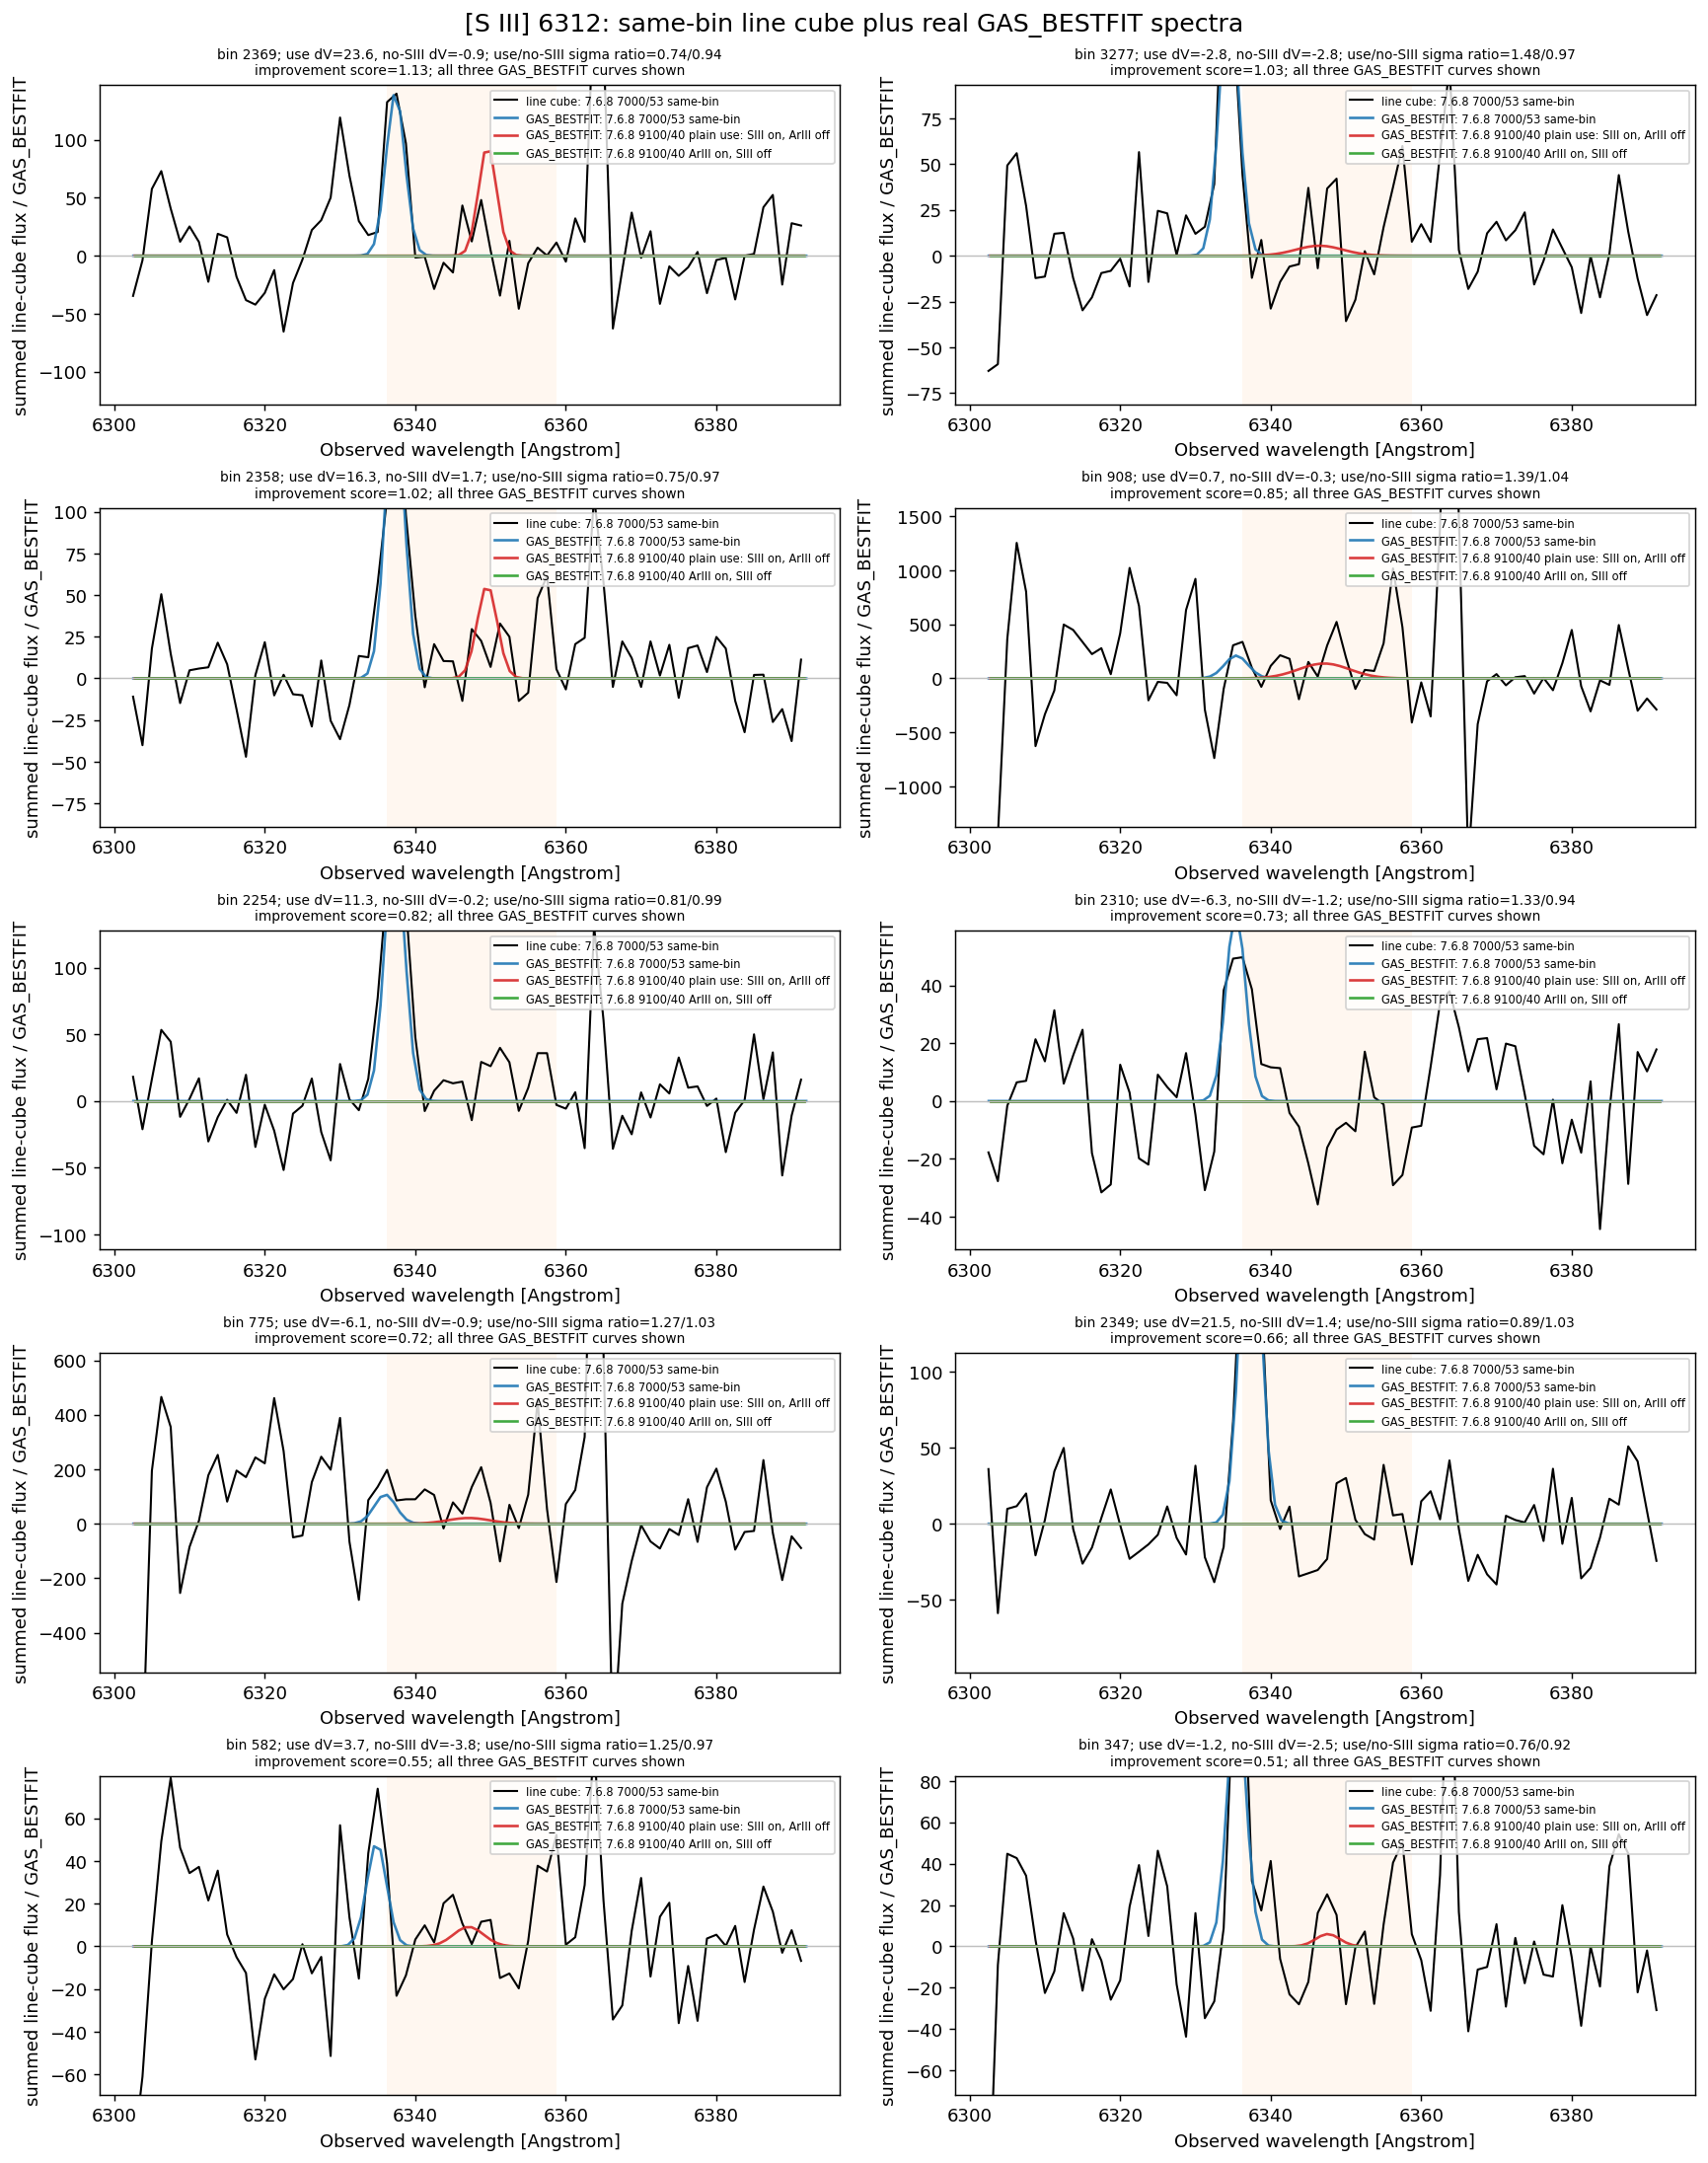

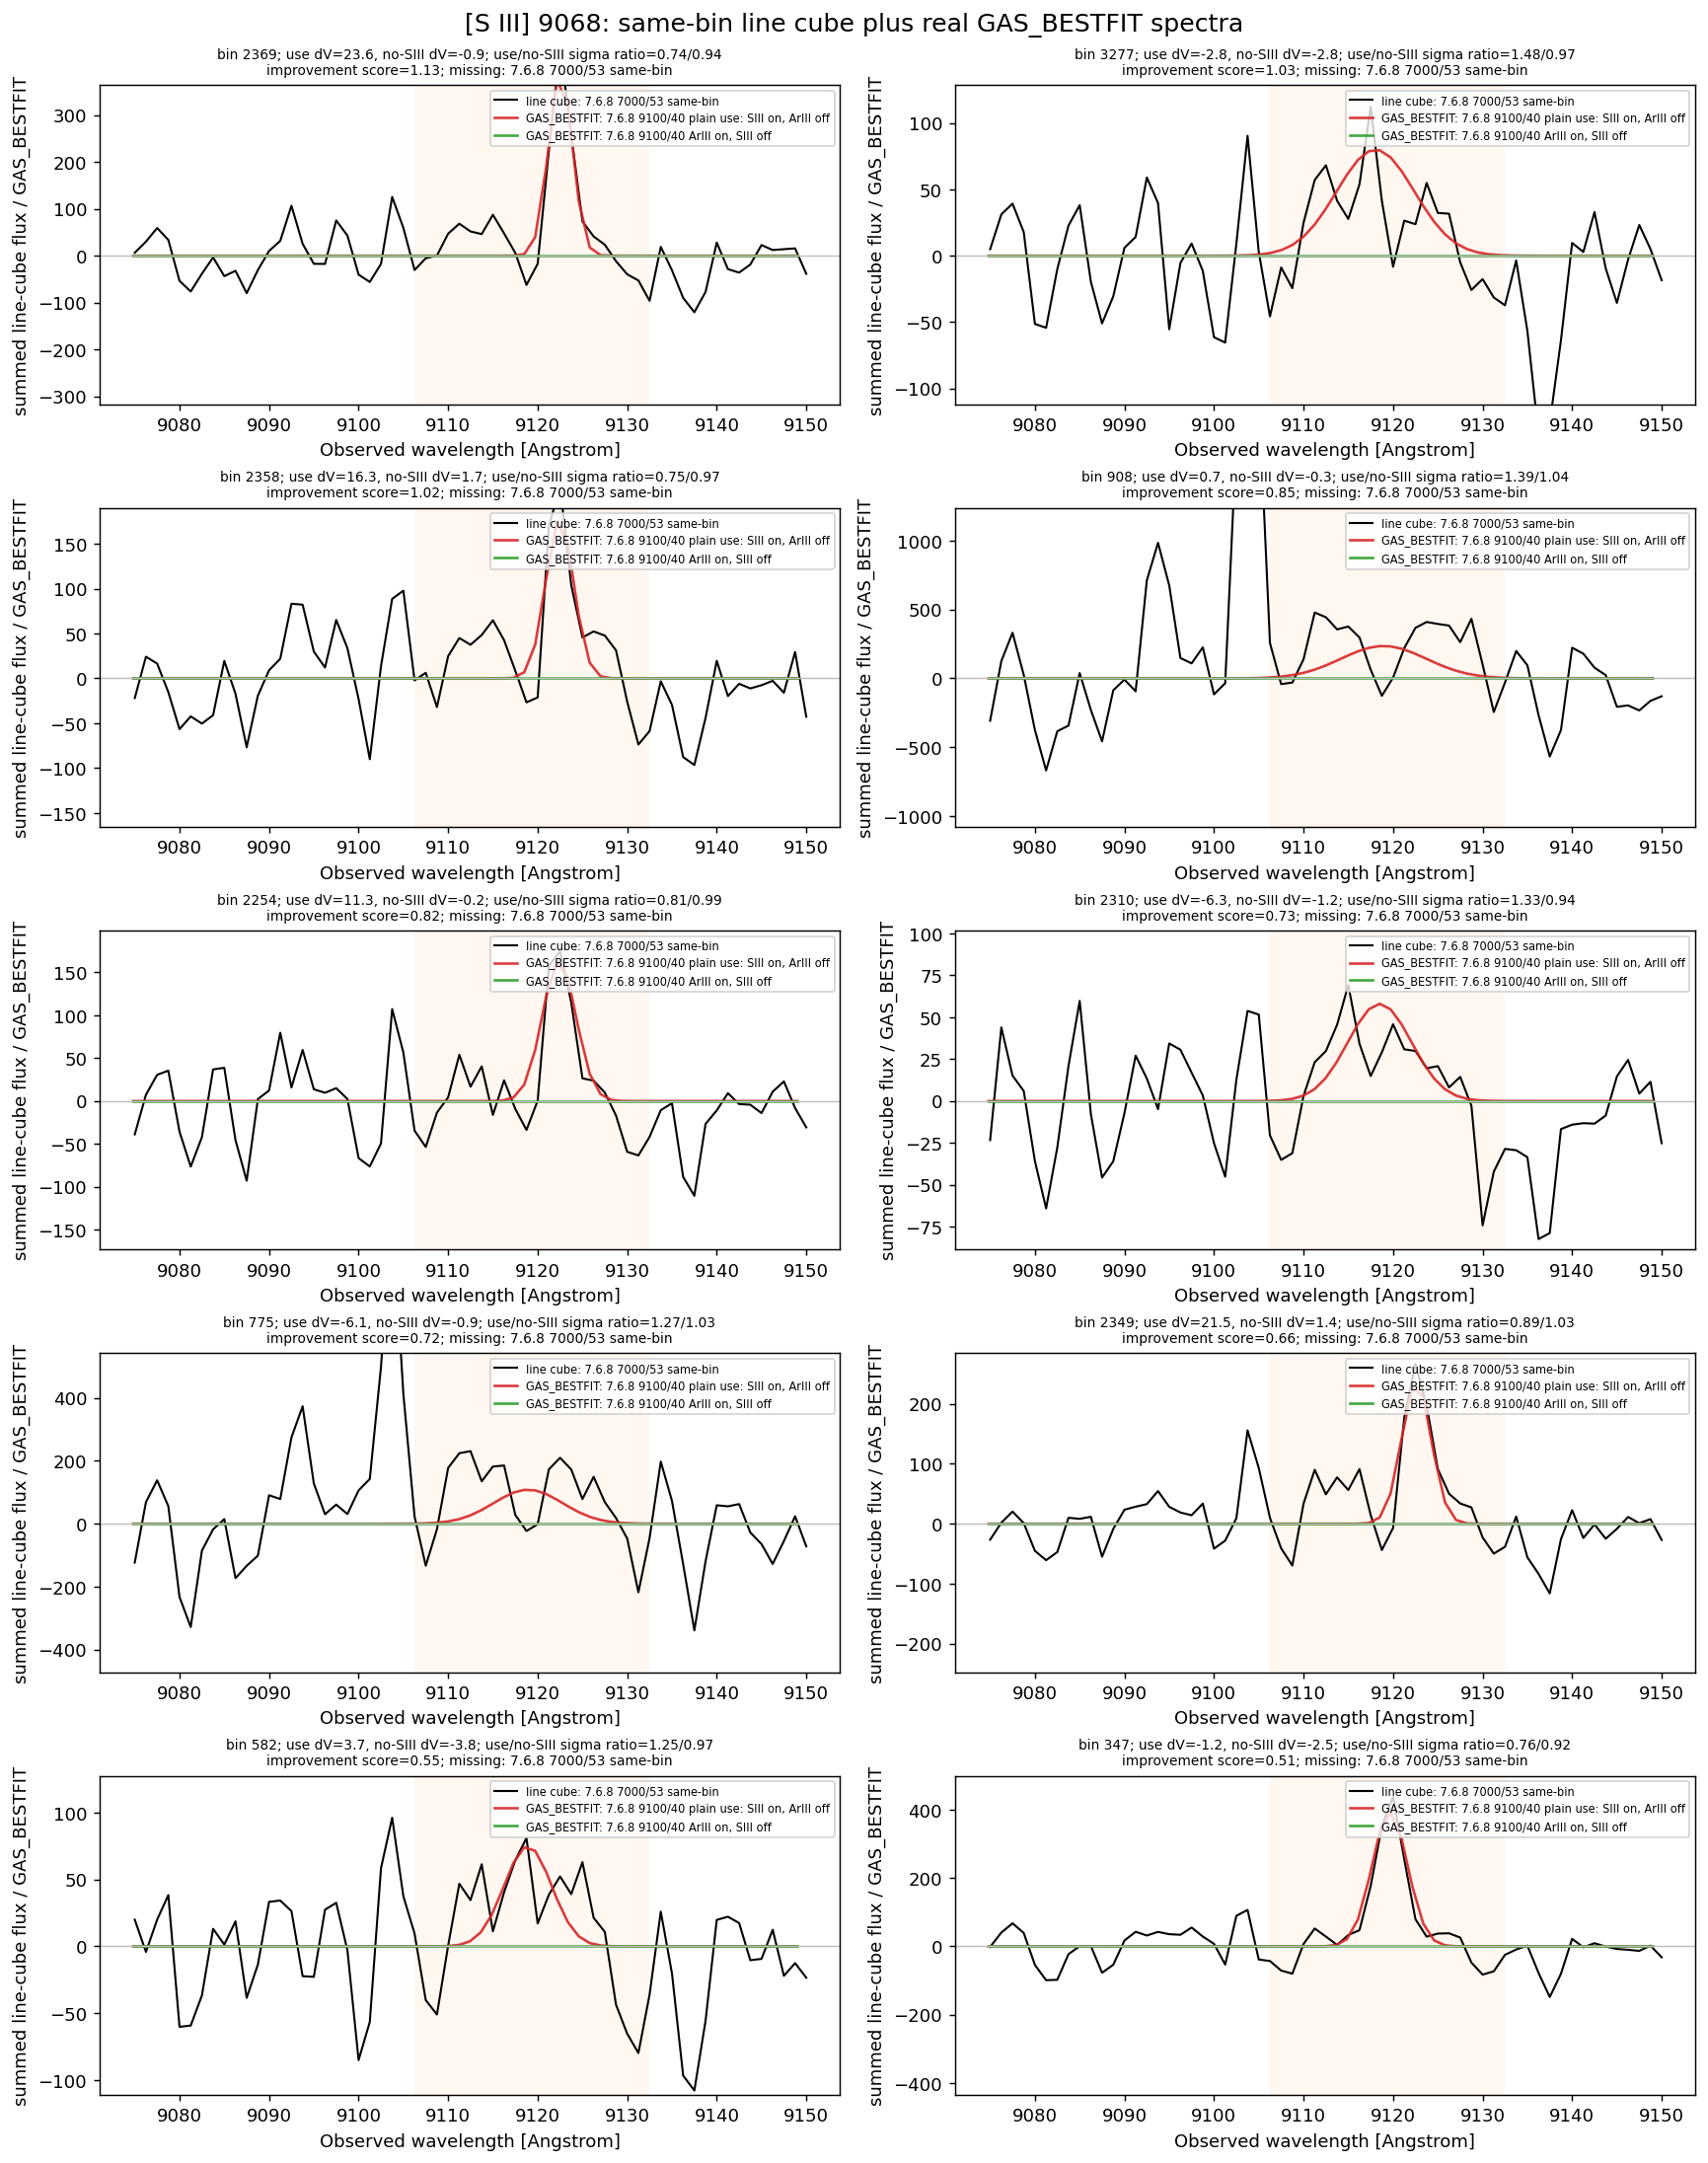

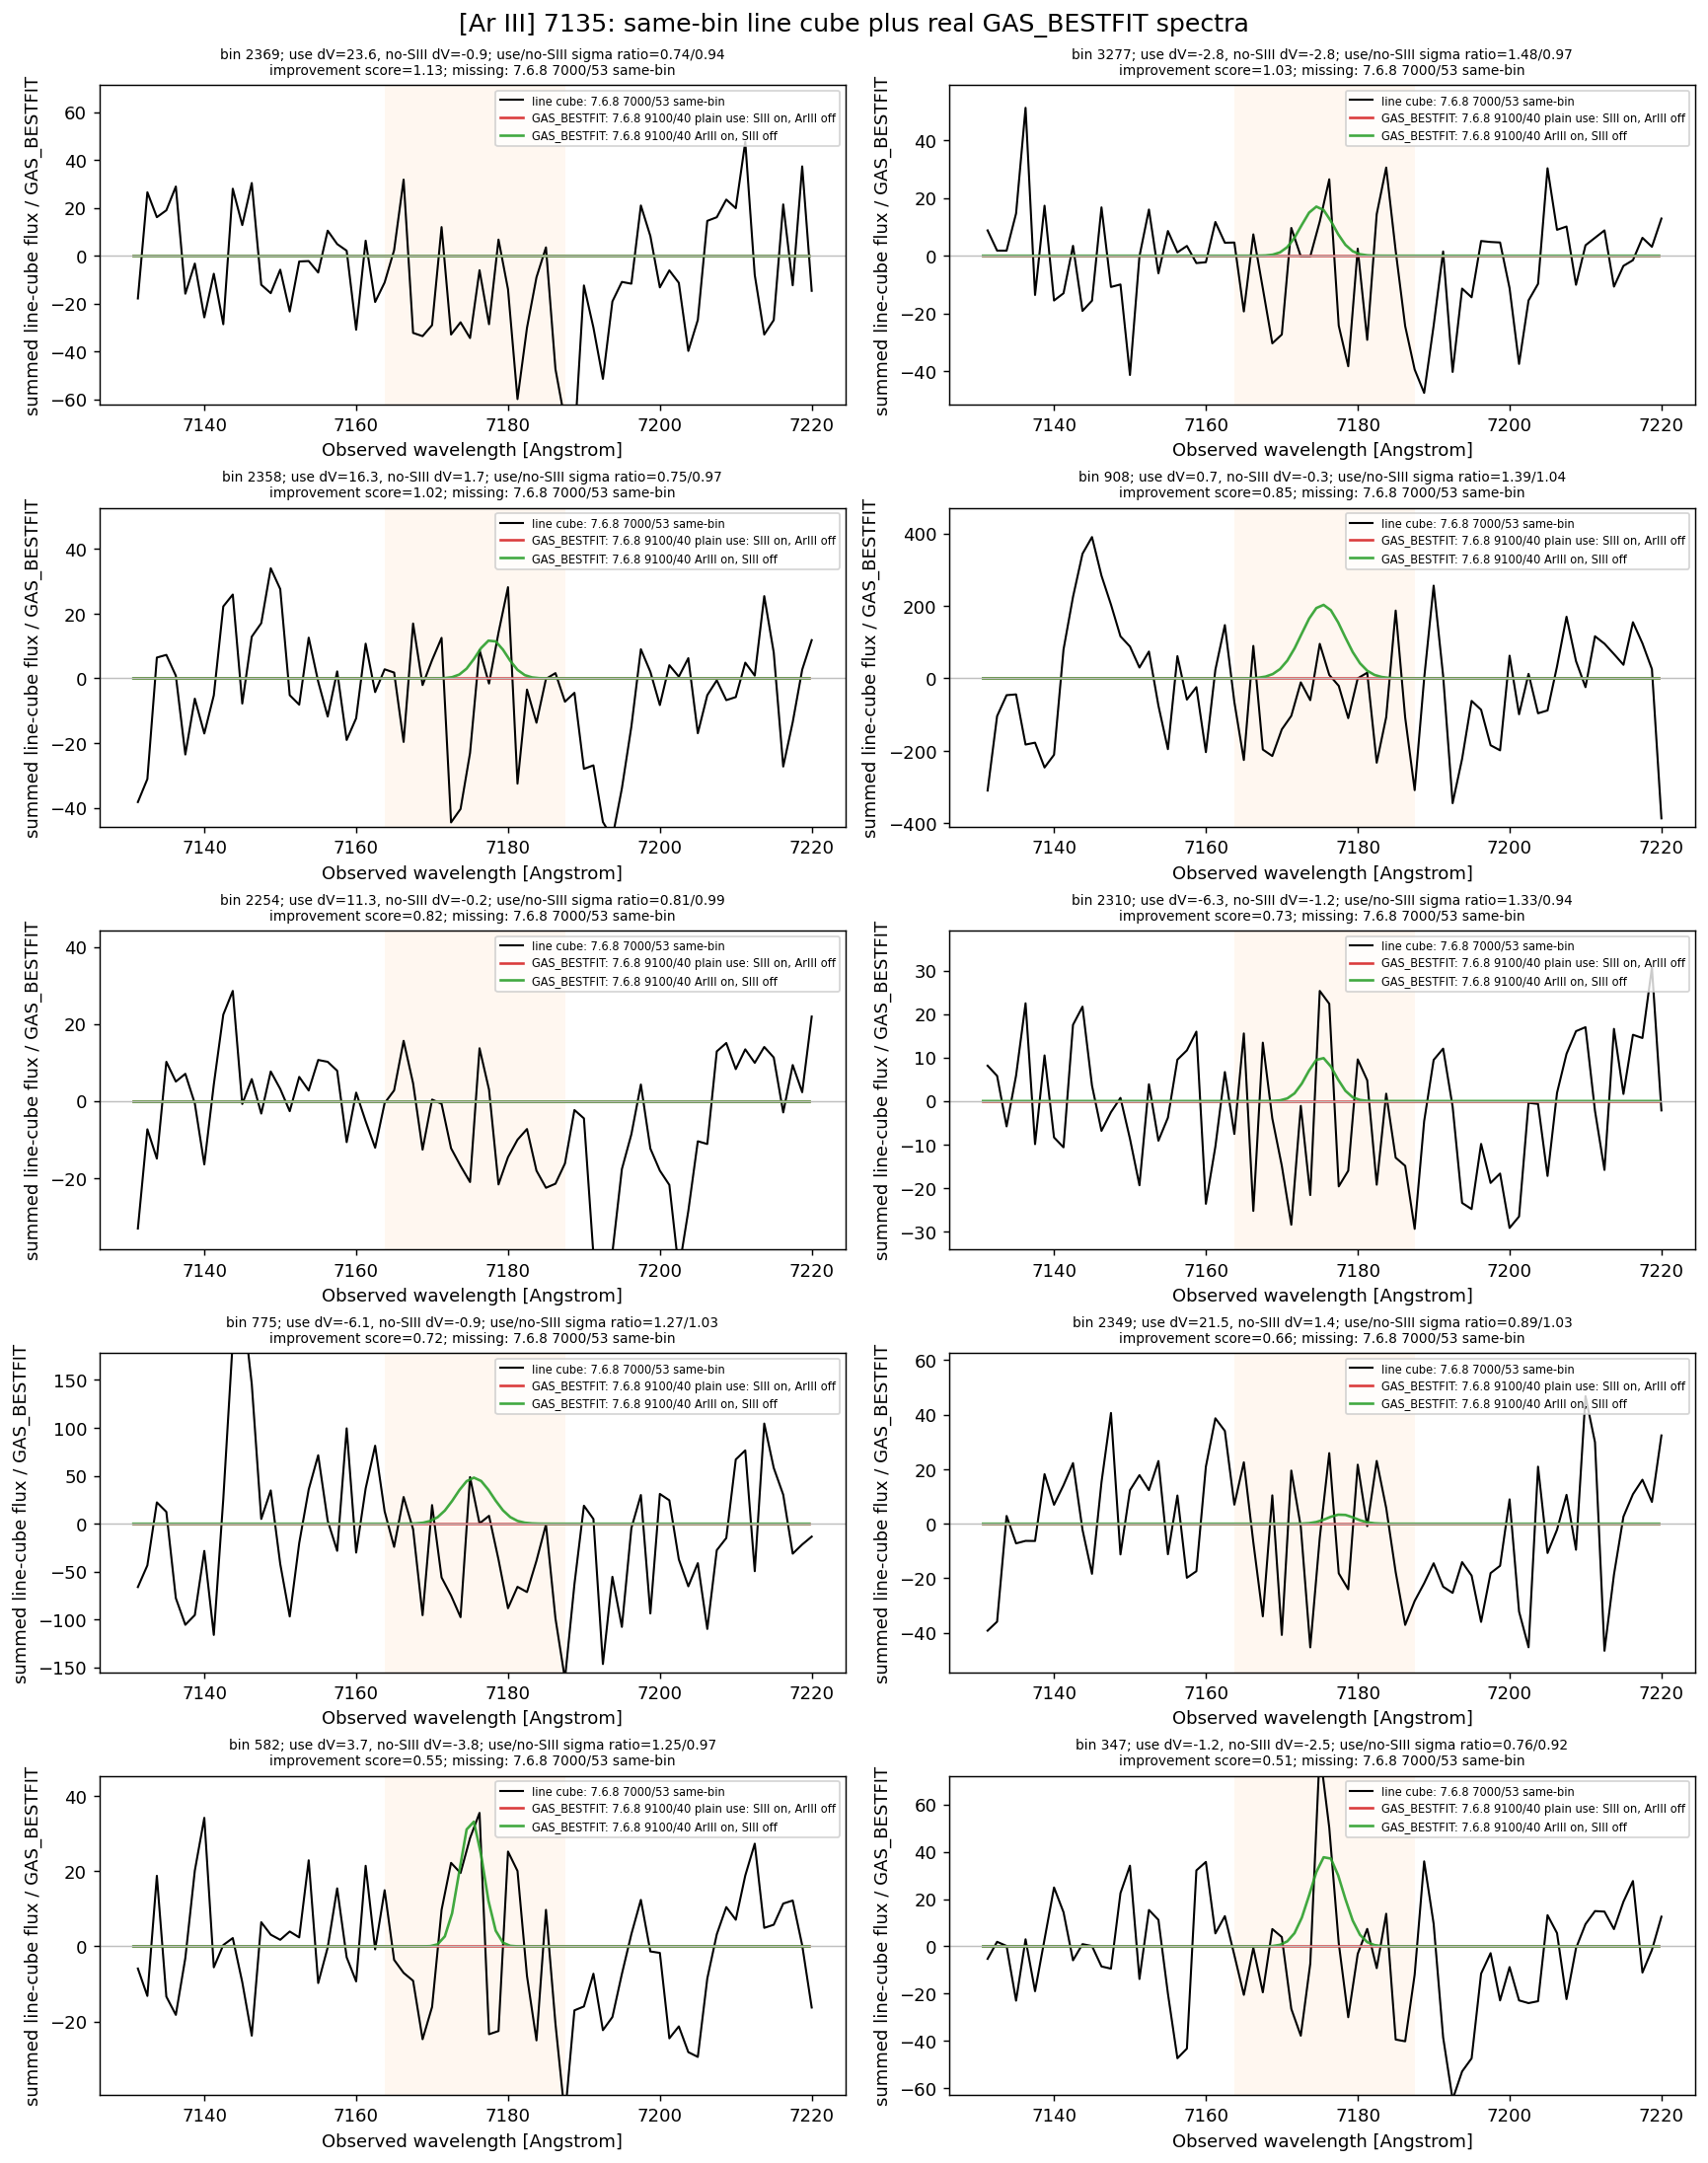

In [10]:
def plot_linecube_spectra(line_id, spectra):
    if not spectra:
        print(f'No spectra for {line_id}')
        return
    n = len(spectra)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13.2, 3.35 * nrows), squeeze=False, constrained_layout=True)
    fig.suptitle(f'{LINE_DEFS[line_id]["label"]}: same-bin line cube plus real GAS_BESTFIT spectra', fontsize=14)

    for ax, spec in zip(axes.ravel(), spectra):
        bin_row = spec['row']
        wave_cube = spec['wave_cube']
        linecube = spec['linecube']
        line_window = spec['line_window']
        ax.plot(wave_cube, linecube, color='black', linewidth=1.15, label=f'line cube: {RUNS[LINECUBE_RUN]["label"]}')
        if np.any(line_window):
            ax.axvspan(wave_cube[line_window].min(), wave_cube[line_window].max(), color='tab:orange', alpha=0.06, linewidth=0)

        for run_key in BESTFIT_RUNS:
            fit = spec['bestfits'].get(run_key)
            if fit is None:
                continue
            ax.plot(
                fit['wave'],
                fit['model'],
                color=RUNS[run_key]['color'],
                linewidth=1.45,
                alpha=0.90,
                label=f'GAS_BESTFIT: {RUNS[run_key]["label"]}',
            )

        plotted_values = [linecube[np.isfinite(linecube)]]
        for fit in spec['bestfits'].values():
            plotted_values.append(fit['model'][np.isfinite(fit['model'])])
        finite_values = np.concatenate([values for values in plotted_values if values.size])
        y_scale = np.nanpercentile(np.abs(finite_values), 98) if finite_values.size else 1.0
        y_scale = y_scale if np.isfinite(y_scale) and y_scale > 0 else 1.0
        ax.axhline(0, color='0.75', linewidth=0.8)
        ax.set_ylim(-1.35 * y_scale, 1.55 * y_scale)
        ax.set_xlabel('Observed wavelength [Angstrom]')
        ax.set_ylabel('summed line-cube flux / GAS_BESTFIT')

        missing = [RUNS[run_key]['label'] for run_key in BESTFIT_RUNS if run_key not in spec['bestfits']]
        coverage_note = 'missing: ' + '; '.join(missing) if missing else 'all three GAS_BESTFIT curves shown'
        title = (
            f'bin {int(bin_row["bin_id"])}; use dV={bin_row["use_delta_vel"]:.1f}, '
            f'no-SIII dV={bin_row["nosiii_delta_vel"]:.1f}; '
            f'use/no-SIII sigma ratio={bin_row["use_sigma_ratio"]:.2f}/{bin_row["nosiii_sigma_ratio"]:.2f}'
        )
        subtitle = f'improvement score={bin_row["use_to_nosiii_improvement_score"]:.2f}; {coverage_note}'
        ax.set_title(title + '\n' + subtitle, fontsize=7.6)
        ax.legend(loc='upper right', fontsize=6.3, frameon=True)

    for ax in axes.ravel()[len(spectra):]:
        ax.axis('off')
    plt.show()

for line_id in ['SIII6312', 'SIII9068', 'ARIII7135']:
    plot_linecube_spectra(line_id, linecube_spectra[line_id])


## Skyline / Red-Edge Residual Check With Line And Continuum Cubes

Here `skyline residual` means a spectral feature that behaves like an observational residual rather than real SIII or ArIII emission: it appears even where OIII is weak, it is broad or edge-like in the continuum-subtracted line cube, and it is not simply a sharp stellar-continuum feature in the continuum cube. This is the check that decides whether SIII is pulling OIII because pPXF is fitting residual structure rather than real SIII.


Low-OIII spaxels used for sky-like median: 995
Selected-bin spaxels used for median: 675


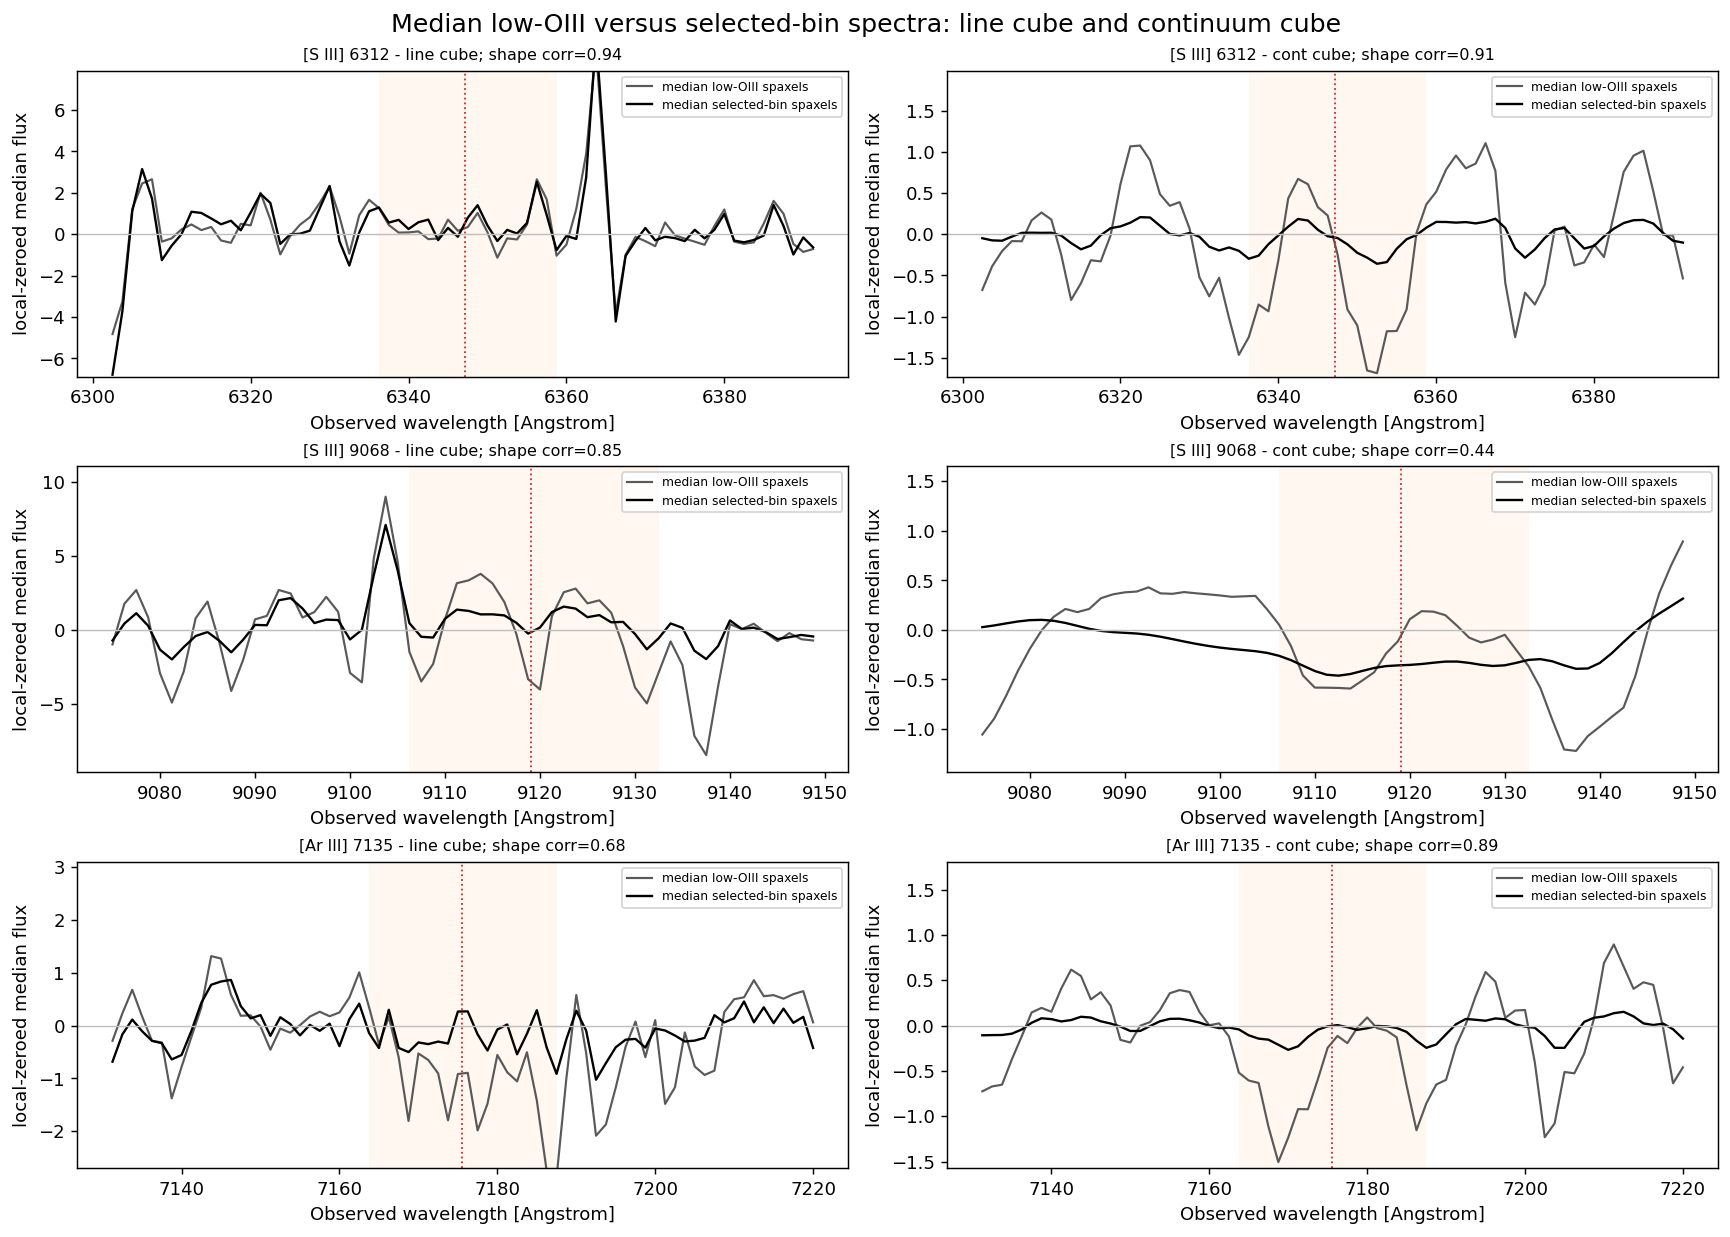

,line_id,cube_kind,low_oiii_peak_abs_over_sideband,selected_peak_abs_over_sideband,low_oiii_line_window_rms_over_sideband,selected_line_window_rms_over_sideband,low_selected_shape_corr,low_oiii_peak_offset_a,selected_peak_offset_a
0,SIII6312,line_cube,3.423318,3.591532,0.658385,0.701931,0.944543,9.057074,9.057074
1,SIII6312,cont_cube,3.102025,2.786174,1.658927,1.611308,0.911216,5.307074,5.307074
2,SIII9068,line_cube,2.940200,1.765364,2.028059,0.869793,0.849333,12.174172,3.424172
3,SIII9068,cont_cube,2.040819,3.741065,1.209839,0.317577,0.439896,-5.325828,-6.575828
4,ARIII7135,line_cube,4.284083,2.860027,1.006413,0.766197,0.682855,11.992193,11.992193
5,ARIII7135,cont_cube,3.193139,2.983203,1.378875,0.868512,0.885802,-6.757807,-5.507807


,line_id,cube_kind,n_bins,median_peak_abs_over_sideband,p90_peak_abs_over_sideband,median_line_window_rms_over_sideband,median_abs_peak_offset_a,median_integral_snr
0,ARIII7135,cont_cube,4032,3.433725,3.812986,0.921063,4.257807,-4.814151
1,ARIII7135,line_cube,4032,2.906008,4.248805,1.073165,10.742193,-2.984875
2,SIII6312,cont_cube,4032,2.604691,2.899468,1.366550,6.557074,-2.834161
3,SIII6312,line_cube,4032,2.574051,4.185104,0.968814,9.057074,1.243806
4,SIII9068,cont_cube,4032,2.172277,2.690554,0.608841,12.174172,6.577636
5,SIII9068,line_cube,4032,2.765336,4.067911,1.514973,10.325828,0.687981


,line_id,cube_kind,n_selected_bins,median_peak_abs_over_sideband,median_line_window_rms_over_sideband,median_abs_peak_offset_a,median_integral_snr
0,ARIII7135,cont_cube,10,3.316674,0.822373,4.257807,-4.683069
1,ARIII7135,line_cube,10,2.381412,1.293996,11.992193,-1.678252
2,SIII6312,cont_cube,10,2.580390,1.340481,6.557074,-2.839974
3,SIII6312,line_cube,10,3.495105,1.011099,9.692926,1.915100
4,SIII9068,cont_cube,10,2.227621,0.655284,13.424172,6.962864
5,SIII9068,line_cube,10,4.882638,1.505081,3.424172,3.300298


,line_id,cube_kind,bin_id,n_spaxels,sideband_rms,line_window_rms,line_window_rms_over_sideband,peak_abs_over_sideband,peak_wave_offset_from_systemic_a,line_integral,line_integral_sideband_snr
22529,ARIII7135,cont_cube,2369,16,7.531109,4.741807,0.629629,3.657912,-3.007807,-204.635866,-4.860689
23437,ARIII7135,cont_cube,3277,8,4.793828,6.406282,1.336361,3.623769,-5.507807,-149.998534,-5.597313
20507,ARIII7135,cont_cube,347,11,7.384496,7.167412,0.970603,3.571733,-4.257807,-213.848743,-5.180371
20742,ARIII7135,cont_cube,582,7,4.928692,4.851389,0.984316,3.524610,-5.507807,-147.640978,-5.358586
20935,ARIII7135,cont_cube,775,149,20.422564,20.733322,1.015216,3.346347,-4.257807,-631.999502,-5.535814
22414,ARIII7135,cont_cube,2254,9,6.757145,4.099387,0.606674,3.287001,-3.007807,-159.228422,-4.215337
22518,ARIII7135,cont_cube,2358,10,7.179244,3.841142,0.535034,3.230796,-3.007807,-145.708798,-3.630630
22470,ARIII7135,cont_cube,2310,4,5.821382,4.518768,0.776236,3.123199,-5.507807,-146.618623,-4.505449
21068,ARIII7135,cont_cube,908,451,37.203455,32.311551,0.868509,2.983197,-5.507807,-933.156136,-4.486896
22509,ARIII7135,cont_cube,2349,10,8.224872,3.652425,0.444071,2.945206,-3.007807,-150.439995,-3.271969


In [11]:
low_oiii_mask = valid & (fluxerr_maps[BASELINE_RUN] < 3)
selected_mask = np.zeros_like(valid, dtype=bool)
selected_mask[valid] = np.isin(
    baseline_bins[valid].astype(int),
    siii_driver_bins['bin_id'].astype(int).to_numpy(),
)
print(f'Low-OIII spaxels used for sky-like median: {int(np.count_nonzero(low_oiii_mask)):,}')
print(f'Selected-bin spaxels used for median: {int(np.count_nonzero(selected_mask)):,}')


def median_cube_spectrum(cube_kind, line_id, mask, wave_half_width=45.0, line_half_width=12.0, continuum_inner=20.0):
    rest_air_a = LINE_DEFS[line_id]['rest_air_a']
    systemic_center = rest_air_a * (1.0 + REDSHIFT)
    wave, slab = get_cube_slab(cube_kind, rest_air_a, wave_half_width=wave_half_width)
    if slab.size == 0 or not np.any(mask):
        return wave, np.full(wave.shape, np.nan), np.full(wave.shape, False, dtype=bool), {}
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        spectrum = np.nanmedian(slab[:, mask], axis=1)
    corrected, zero, sideband, line_window, metrics = spectral_profile_metrics(
        wave,
        spectrum,
        systemic_center,
        line_half_width=line_half_width,
        continuum_inner=continuum_inner,
    )
    return wave, corrected, line_window, metrics


def spectral_shape_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    ok = np.isfinite(a) & np.isfinite(b)
    if np.count_nonzero(ok) < 4:
        return np.nan
    if robust_sigma(a[ok]) == 0 or robust_sigma(b[ok]) == 0:
        return np.nan
    return float(np.corrcoef(a[ok], b[ok])[0, 1])


def summed_bin_spectra_for_cube(cube_kind, line_id, wave_half_width=45.0):
    rest_air_a = LINE_DEFS[line_id]['rest_air_a']
    wave, slab = get_cube_slab(cube_kind, rest_air_a, wave_half_width=wave_half_width)
    if slab.size == 0:
        return wave, {}, np.array([])
    finite = valid & np.isfinite(baseline_bins) & (baseline_bins >= 0)
    flat_bin_ids = baseline_bins[finite].astype(int)
    max_bin_id = int(np.nanmax(flat_bin_ids))
    counts = np.bincount(flat_bin_ids, minlength=max_bin_id + 1)
    summed = np.empty((slab.shape[0], max_bin_id + 1), dtype=float)
    for i in range(slab.shape[0]):
        weights = np.nan_to_num(slab[i][finite], nan=0.0)
        summed[i] = np.bincount(flat_bin_ids, weights=weights, minlength=max_bin_id + 1)
    spectra_by_bin = {
        int(bin_id): summed[:, int(bin_id)]
        for bin_id in bin_table['bin_id'].astype(int)
        if int(bin_id) <= max_bin_id and counts[int(bin_id)] > 0
    }
    return wave, spectra_by_bin, counts

profile_rows = []
fig, axes = plt.subplots(3, 2, figsize=(13.2, 9.4), constrained_layout=True)
fig.suptitle('Median low-OIII versus selected-bin spectra: line cube and continuum cube', fontsize=14)
for row_idx, spec in enumerate(cube_line_specs):
    line_id = spec['line_id']
    systemic_center = LINE_DEFS[line_id]['rest_air_a'] * (1.0 + REDSHIFT)
    for col_idx, cube_kind in enumerate(['line_cube', 'cont_cube']):
        ax = axes[row_idx, col_idx]
        wave_low, low_spec, low_window, low_metrics = median_cube_spectrum(
            cube_kind,
            line_id,
            low_oiii_mask,
            wave_half_width=spec['wave_half_width'],
            line_half_width=spec['line_half_width'],
            continuum_inner=spec['continuum_inner'],
        )
        wave_sel, sel_spec, sel_window, sel_metrics = median_cube_spectrum(
            cube_kind,
            line_id,
            selected_mask,
            wave_half_width=spec['wave_half_width'],
            line_half_width=spec['line_half_width'],
            continuum_inner=spec['continuum_inner'],
        )
        corr = spectral_shape_corr(low_spec, sel_spec)
        profile_rows.append({
            'line_id': line_id,
            'cube_kind': cube_kind,
            'low_oiii_peak_abs_over_sideband': low_metrics.get('peak_abs_over_sideband', np.nan),
            'selected_peak_abs_over_sideband': sel_metrics.get('peak_abs_over_sideband', np.nan),
            'low_oiii_line_window_rms_over_sideband': low_metrics.get('line_window_rms_over_sideband', np.nan),
            'selected_line_window_rms_over_sideband': sel_metrics.get('line_window_rms_over_sideband', np.nan),
            'low_selected_shape_corr': corr,
            'low_oiii_peak_offset_a': low_metrics.get('peak_wave_offset_from_systemic_a', np.nan),
            'selected_peak_offset_a': sel_metrics.get('peak_wave_offset_from_systemic_a', np.nan),
        })
        ax.plot(wave_low, low_spec, color='0.35', linewidth=1.2, label='median low-OIII spaxels')
        ax.plot(wave_sel, sel_spec, color='black', linewidth=1.3, label='median selected-bin spaxels')
        if np.any(sel_window):
            ax.axvspan(wave_sel[sel_window].min(), wave_sel[sel_window].max(), color='tab:orange', alpha=0.06, linewidth=0)
        ax.axvline(systemic_center, color='tab:red', linestyle=':', linewidth=1)
        ax.axhline(0, color='0.75', linewidth=0.8)
        finite_vals = np.concatenate([low_spec[np.isfinite(low_spec)], sel_spec[np.isfinite(sel_spec)]])
        y_scale = np.nanpercentile(np.abs(finite_vals), 98) if finite_vals.size else 1.0
        y_scale = y_scale if np.isfinite(y_scale) and y_scale > 0 else 1.0
        ax.set_ylim(-1.35 * y_scale, 1.55 * y_scale)
        ax.set_title(f'{LINE_DEFS[line_id]["label"]} - {cube_kind.replace("_", " ")}; shape corr={corr:.2f}', fontsize=8.8)
        ax.set_xlabel('Observed wavelength [Angstrom]')
        ax.set_ylabel('local-zeroed median flux')
        ax.legend(loc='upper right', fontsize=6.8, frameon=True)
plt.show()

median_profile_summary = pd.DataFrame(profile_rows)
display(median_profile_summary)

cube_residual_rows = []
for spec in cube_line_specs:
    line_id = spec['line_id']
    systemic_center = LINE_DEFS[line_id]['rest_air_a'] * (1.0 + REDSHIFT)
    for cube_kind in ['line_cube', 'cont_cube']:
        wave, spectra_by_bin, counts = summed_bin_spectra_for_cube(cube_kind, line_id, wave_half_width=spec['wave_half_width'])
        for bin_id, spectrum in spectra_by_bin.items():
            corrected, zero, sideband, line_window, metrics = spectral_profile_metrics(
                wave,
                spectrum,
                systemic_center,
                line_half_width=spec['line_half_width'],
                continuum_inner=spec['continuum_inner'],
            )
            cube_residual_rows.append({
                'line_id': line_id,
                'cube_kind': cube_kind,
                'bin_id': int(bin_id),
                'n_spaxels': int(counts[int(bin_id)]) if len(counts) > int(bin_id) else np.nan,
                **metrics,
            })
cube_residual_metric_table = pd.DataFrame(cube_residual_rows)

skyline_residual_summary = (
    cube_residual_metric_table
    .groupby(['line_id', 'cube_kind'], as_index=False)
    .agg(
        n_bins=('bin_id', 'size'),
        median_peak_abs_over_sideband=('peak_abs_over_sideband', 'median'),
        p90_peak_abs_over_sideband=('peak_abs_over_sideband', lambda x: float(np.nanpercentile(x, 90))),
        median_line_window_rms_over_sideband=('line_window_rms_over_sideband', 'median'),
        median_abs_peak_offset_a=('peak_wave_offset_from_systemic_a', lambda x: float(np.nanmedian(np.abs(x)))),
        median_integral_snr=('line_integral_sideband_snr', 'median'),
    )
)
selected_cube_residual_metrics = cube_residual_metric_table[cube_residual_metric_table['bin_id'].isin(siii_driver_bins['bin_id'].astype(int))].copy()
selected_residual_summary = (
    selected_cube_residual_metrics
    .groupby(['line_id', 'cube_kind'], as_index=False)
    .agg(
        n_selected_bins=('bin_id', 'size'),
        median_peak_abs_over_sideband=('peak_abs_over_sideband', 'median'),
        median_line_window_rms_over_sideband=('line_window_rms_over_sideband', 'median'),
        median_abs_peak_offset_a=('peak_wave_offset_from_systemic_a', lambda x: float(np.nanmedian(np.abs(x)))),
        median_integral_snr=('line_integral_sideband_snr', 'median'),
    )
)
display(skyline_residual_summary)
display(selected_residual_summary)
display(selected_cube_residual_metrics.sort_values(['line_id', 'cube_kind', 'peak_abs_over_sideband'], ascending=[True, True, False]))


## Correlate Fitted Faint-Line Strength, Cube Residuals, And OIII Failure

This section asks whether the fitted SIII or ArIII significance tracks the OIII degradation. The second row is the direct residual check: if fitted `SIII9068` Flux/Err tracks the line-cube residual metric much more than the continuum-cube metric, that supports the sky/red-edge residual interpretation.


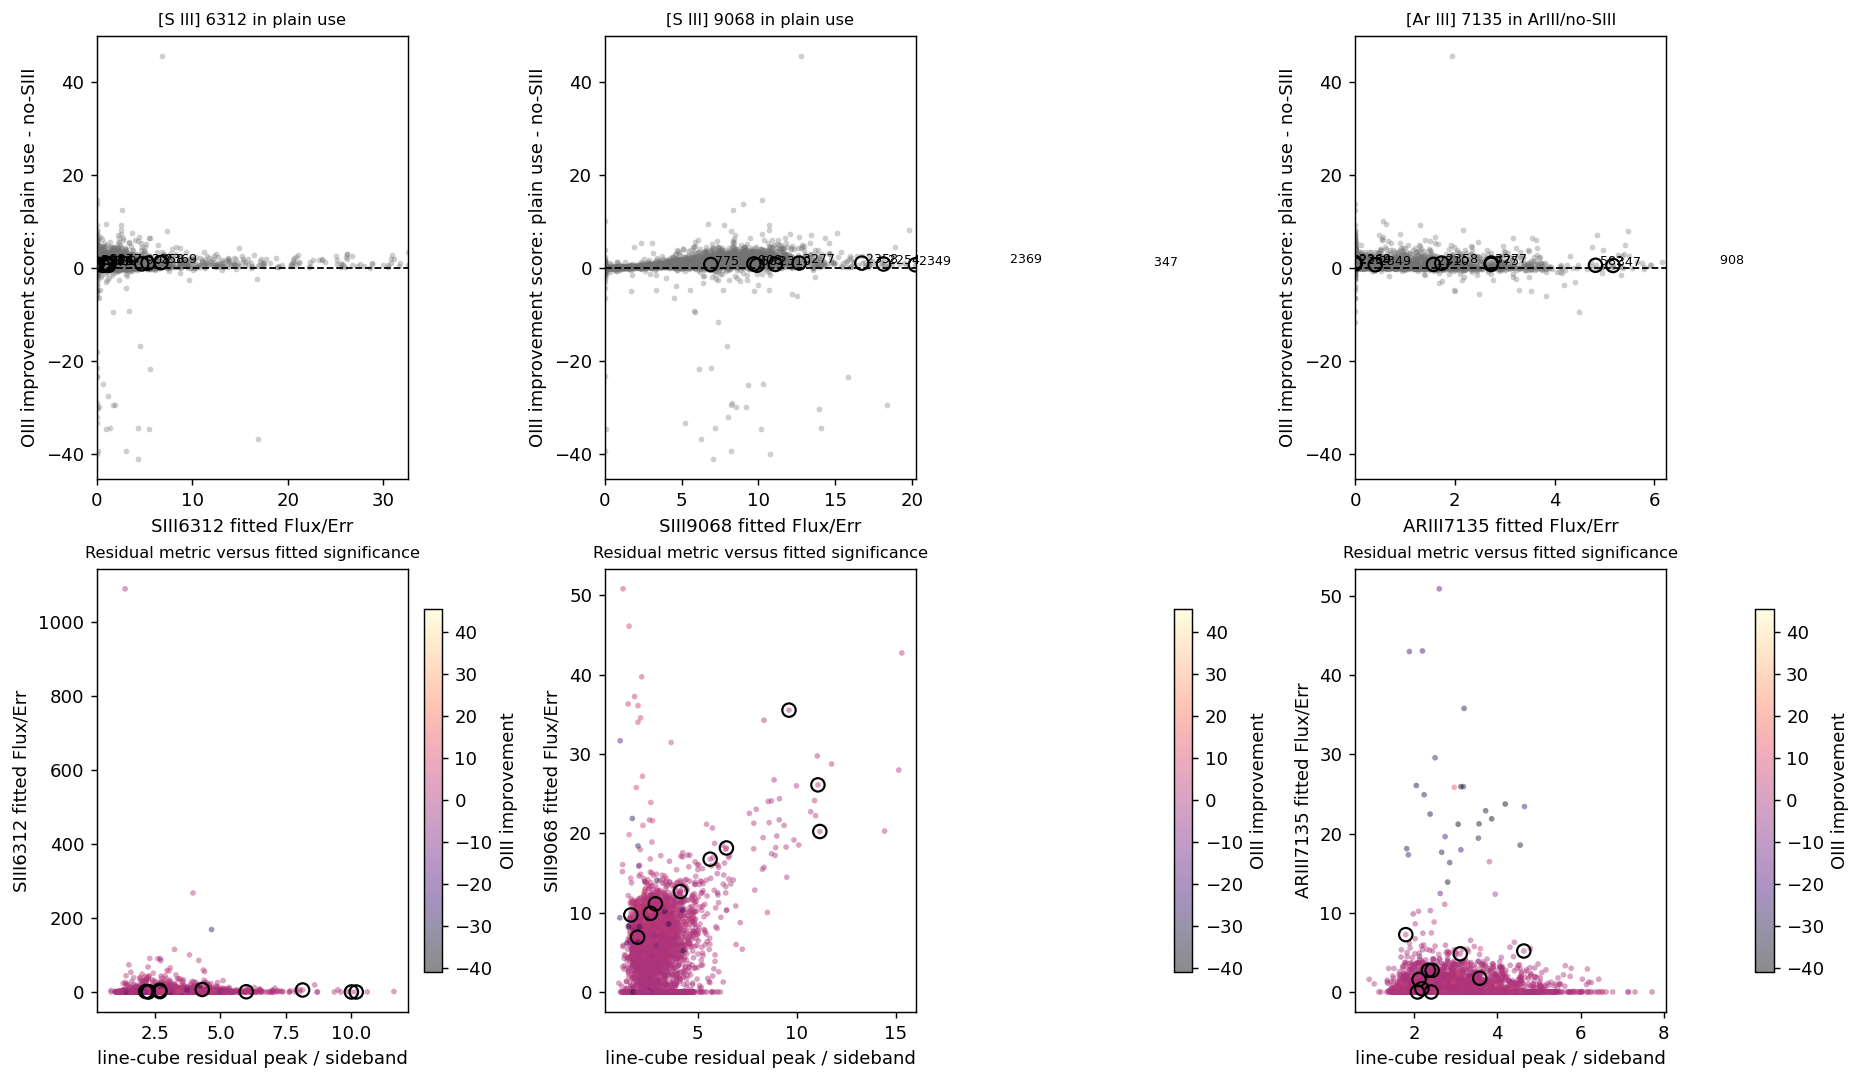

,line_id,run_key,n_bins,spearman_fluxerr_vs_oiii_improvement,spearman_linecube_residual_vs_fluxerr,spearman_contcube_residual_vs_fluxerr,median_linecube_residual_peak_over_sideband_selected,median_contcube_residual_peak_over_sideband_selected
0,SIII6312,use_with_siii,4032,0.029357,0.072628,0.031617,3.495105,2.580390
1,SIII9068,use_with_siii,4032,0.700964,0.143030,0.023388,4.882638,2.227621
2,ARIII7135,ariii_no_siii,4032,-0.123173,-0.075531,-0.023692,2.381412,3.316674


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(14.2, 8.2), constrained_layout=True)
residual_vs_fitted_rows = []
for col_idx, spec in enumerate(DIAGNOSTIC_LINES):
    subset = line_bin_table[(line_bin_table['run_key'] == spec['run_key']) & (line_bin_table['line_id'] == spec['line_id'])].copy()
    merged = subset.merge(
        bin_table[['bin_id', 'use_badness_score', 'nosiii_badness_score', 'use_to_nosiii_improvement_score', 'use_abs_delta_vel', 'nosiii_abs_delta_vel']],
        on='bin_id',
        how='left',
        suffixes=('', '_oiii'),
    )
    line_resid = cube_residual_metric_table[
        (cube_residual_metric_table['line_id'] == spec['line_id']) &
        (cube_residual_metric_table['cube_kind'] == 'line_cube')
    ][['bin_id', 'peak_abs_over_sideband', 'line_window_rms_over_sideband']].rename(columns={
        'peak_abs_over_sideband': 'linecube_peak_abs_over_sideband',
        'line_window_rms_over_sideband': 'linecube_line_window_rms_over_sideband',
    })
    cont_resid = cube_residual_metric_table[
        (cube_residual_metric_table['line_id'] == spec['line_id']) &
        (cube_residual_metric_table['cube_kind'] == 'cont_cube')
    ][['bin_id', 'peak_abs_over_sideband', 'line_window_rms_over_sideband']].rename(columns={
        'peak_abs_over_sideband': 'contcube_peak_abs_over_sideband',
        'line_window_rms_over_sideband': 'contcube_line_window_rms_over_sideband',
    })
    merged = merged.merge(line_resid, on='bin_id', how='left').merge(cont_resid, on='bin_id', how='left')
    selected = merged[merged['bin_id'].isin(siii_driver_bins['bin_id'])]

    ax = axes[0, col_idx]
    ax.scatter(merged['line_fluxerr'], merged['use_to_nosiii_improvement_score'], s=10, alpha=0.35, color='0.45', linewidths=0)
    ax.scatter(selected['line_fluxerr'], selected['use_to_nosiii_improvement_score'], s=55, facecolors='none', edgecolors='black', linewidths=1.2)
    for _, row in selected.iterrows():
        ax.text(row['line_fluxerr'], row['use_to_nosiii_improvement_score'], f' {int(row["bin_id"])}', fontsize=7)
    x_hi = np.nanpercentile(merged['line_fluxerr'], 99) if np.isfinite(merged['line_fluxerr']).any() else 1.0
    ax.set_xlim(left=min(0, np.nanmin(merged['line_fluxerr']) if np.isfinite(merged['line_fluxerr']).any() else 0), right=max(x_hi, 3.0))
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel(f'{spec["line_id"]} fitted Flux/Err')
    ax.set_ylabel('OIII improvement score: plain use - no-SIII')
    ax.set_title(spec['label'], fontsize=9)

    ax = axes[1, col_idx]
    color_values = merged['use_to_nosiii_improvement_score']
    finite_color = np.isfinite(color_values)
    scatter = ax.scatter(
        merged['linecube_peak_abs_over_sideband'],
        merged['line_fluxerr'],
        c=np.where(finite_color, color_values, np.nan),
        s=10,
        alpha=0.45,
        cmap='magma',
        linewidths=0,
    )
    ax.scatter(selected['linecube_peak_abs_over_sideband'], selected['line_fluxerr'], s=55, facecolors='none', edgecolors='black', linewidths=1.2)
    ax.set_xlabel('line-cube residual peak / sideband')
    ax.set_ylabel(f'{spec["line_id"]} fitted Flux/Err')
    ax.set_title('Residual metric versus fitted significance', fontsize=9)
    fig.colorbar(scatter, ax=ax, shrink=0.82, label='OIII improvement')

    finite = merged[['line_fluxerr', 'use_to_nosiii_improvement_score', 'linecube_peak_abs_over_sideband', 'contcube_peak_abs_over_sideband']].replace([np.inf, -np.inf], np.nan)
    residual_vs_fitted_rows.append({
        'line_id': spec['line_id'],
        'run_key': spec['run_key'],
        'n_bins': int(len(merged)),
        'spearman_fluxerr_vs_oiii_improvement': float(finite['line_fluxerr'].corr(finite['use_to_nosiii_improvement_score'], method='spearman')),
        'spearman_linecube_residual_vs_fluxerr': float(finite['linecube_peak_abs_over_sideband'].corr(finite['line_fluxerr'], method='spearman')),
        'spearman_contcube_residual_vs_fluxerr': float(finite['contcube_peak_abs_over_sideband'].corr(finite['line_fluxerr'], method='spearman')),
        'median_linecube_residual_peak_over_sideband_selected': float(np.nanmedian(selected['linecube_peak_abs_over_sideband'])) if len(selected) else np.nan,
        'median_contcube_residual_peak_over_sideband_selected': float(np.nanmedian(selected['contcube_peak_abs_over_sideband'])) if len(selected) else np.nan,
    })
plt.show()

residual_vs_fitted_summary = pd.DataFrame(residual_vs_fitted_rows)
display(residual_vs_fitted_summary)


## Observations From The Executed Diagnostics

1. The OI change is confirmed for the two 9100 test runs: `OI6300` and `OI6363` are commented out in both the plain-use and ArIII/no-SIII configs, while the dedicated `sky` masks at 5577/6300/6363 remain active masks. The old 7000 same-bin reference GAS-map file still contains OI map extensions, so the 7000 reference curve near 6312 should not be used as evidence that OI is absent there.

2. The restored direct residual plots use the sign convention `comparison run - reference`. In particular, the plain-use residual panels are `plain use - 7000/53 same-bin reference`; the previous selected-bin improvement maps are retained only as absolute-error improvement diagnostics, not as signed residuals.

3. The OIII improvement remains after the no-OI update. At OIII `Flux/Err > 20`, the plain-use run has robust OIII velocity scatter `2.37 km/s` and robust log-sigma-ratio scatter `0.0355 dex`; the ArIII/no-SIII run has `0.88 km/s` and `0.0117 dex`. The selected-bin map scale remains tied to the selected bins: `+/-25 km/s` for velocity residuals and `+/-0.20 dex` for log sigma-ratio residuals.

4. `SIII9068` is still the fitted line with real leverage. In the plain-use GAS maps it has median fitted `Flux/Err = 5.71`, with `2203` bins above `Flux/Err > 5` and `557` bins above `Flux/Err > 10`. `SIII6312` is much weaker overall (`median Flux/Err = 0.39`, `412` bins above 5), and `ArIII7135` is sparse (`median Flux/Err = 0`, `63` bins above 5).

5. The real `GAS_BESTFIT` spectra now make the difference clearer. After OI is removed from the 9100 plain-use run, the median selected-bin `SIII6312` model peak is only about `7.5`, while the median `SIII9068` model peak is about `168`. The ArIII/no-SIII run has the expected ArIII model peak around `14`, but no SIII9068 model. So the OIII damage is not coming from SIII6312; it is dominated by the SIII9068 constraint.

6. The red-edge / sky-residual evidence is significant but not a one-number proof. `SIII9068` lands at `9119.08 Angstrom`, only `30.9 Angstrom` from the red edge of the cube and outside the nominal `4800-9100` observed-frame window. For the selected bins, the SIII9068 line-cube residual peak/sideband is `4.88`, versus `2.23` in the continuum cube. Across all bins, the SIII9068 line cube has median peak/sideband `2.77` and p90 `4.07`, larger than the continuum cube median `2.17` and p90 `2.69`.

7. The low-OIII check supports an observational residual component. The low-OIII and selected-bin SIII9068 line-cube profiles have high shape correlation (`0.85`), while the corresponding continuum-cube profiles are much less similar (`0.44`). This means the suspicious SIII9068 structure is not simply a stellar-continuum feature, and it appears even where real OIII-bright nebular emission should be weak.

8. The fitted-line correlation points directly at SIII9068. Spearman correlation between fitted line `Flux/Err` and the OIII improvement score is `0.70` for `SIII9068`, but only `0.03` for `SIII6312` and `-0.12` for `ArIII7135`. The simple line-cube residual metric versus fitted `Flux/Err` is weaker (`0.14` for SIII9068), so the problem is not just one scalar skyline-amplitude trend; it is the combination of a widespread high-significance SIII9068 fit, red-edge residual structure, and tying that line into the OIII kinematic component.


## Interpretation And Next Fitting Test

The current evidence supports this interpretation: ArIII is weaker, but it is also sparse and not strongly correlated with the OIII failure, so tying ArIII to OIII gives it little practical leverage. SIII9068 is different. It is fitted as significant in many bins, it lies at the red edge where the line cube shows residual structure, and because it is tied to OIII through the same kinematic component, pPXF can compromise the shared OIII/SIII velocity and sigma to reduce SIII9068 residuals. That is why removing SIII helps much more than removing ArIII.

This does not mean SIII should never be fitted. It means SIII9068 should not be allowed to determine the OIII kinematics in the same optimization. The safest next strategy is a two-pass fit: first fit the primary gas kinematics from robust lines such as OIII, Halpha, NII, and SII with SIII9068 excluded or masked; then fit SIII fluxes with the OIII kinematics fixed from that first pass, so SIII can be measured without feeding back into OIII.

If a single-pass config is needed, the next test should be `SIII6312` only or an explicit mask/deweighting of the SIII9068 red-edge window. The validation criterion should be: OIII maps remain close to the ArIII/no-SIII result, while SIII fluxes are still measured. A useful concrete pair of next runs would be: `use_SIII6312_only` and `use_SIII9068_masked_or_fixed_kinematics`, then compare their OIII residual maps and SIII flux/error maps against this notebook.


## Optional Save

Uncomment these if you want CSV tables for notes or follow-up checks.


In [13]:
# oi_summary.to_csv('IC3392_OIII_use_vs_ArIII_noSIII_summary_20260514.csv', index=False)
# siii_driver_bins[selected_cols].to_csv('IC3392_SIII_driver_candidate_bins_20260514.csv', index=False)
# line_population_summary.to_csv('IC3392_faint_line_population_summary_20260514.csv', index=False)
# selected_line_table.to_csv('IC3392_selected_bin_faint_line_gas_map_summary_20260514.csv', index=False)
# linecube_metric_table.to_csv('IC3392_selected_bin_linecube_metrics_20260514.csv', index=False)
# median_profile_summary.to_csv('IC3392_median_lowOIII_selected_cube_profile_summary_20260514.csv', index=False)
# skyline_residual_summary.to_csv('IC3392_all_bin_cube_residual_summary_20260514.csv', index=False)
# selected_cube_residual_metrics.to_csv('IC3392_selected_bin_cube_residual_metrics_20260514.csv', index=False)
# residual_vs_fitted_summary.to_csv('IC3392_residual_vs_fitted_summary_20260514.csv', index=False)
